# 02. Late-delivery classification: from plain logistic regression to Random Forest

**Purpose.** Predict, at order approval, whether an order will arrive after its promised delivery date (the late class is about 9% of orders). We first build the plain linear model properly (transformations, variable selection judged on later time periods, odds ratios), then ask whether a Random Forest adds enough to justify its complexity. No model is chosen: every model is scored in exactly the same way on Train (in-sample), CV, Validation, Test (June) and Monitoring (July and August). The headline evaluation is June.

**Contents**
1. Setup
2. Data and split
3. C0: no-skill baseline
4. Stage 1: linear models (transformations, C1, class-weight check, CV-stepwise C2, BIC/AIC stepwise C2B, Lasso, overlap, model key)
5. Class-imbalance experiment (resampling inside CV folds)
6. Stage 2: Random Forest (C3 tuned, C3d default)
7. Evaluation: Train, CV, Validation, June refit
8. Freeze and monitor: July and August
9. Results: comparison, success criteria, overfitting gaps, June deciles and lift, tuning gain, drift
10. Interpretation: odds ratios, hypothesis check, calibration, Random Forest importance
11. Exports and run metadata

**Model key.** Model codes (C0, C1, ...) are the stable keys; every table also shows a readable `Model` column and every figure labels models "Code · short label". Section 4.7 shows the full key with the number of features each model uses (known once selection has run). The labels live in `src/model_labels.py` and the key is repeated in `RESULTS_SUMMARY.md`.

## 1. Setup

Imports, paths and constants. `RUN_RF_SEARCH = False` loads the cached Random Forest search (`python -m src.rf_search --task classification` produced it), so this notebook never re-runs the slow search.

In [1]:
import json
import platform
from pathlib import Path

import imblearn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import statsmodels
from IPython.display import Image, display
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

from src import LOOKBACK, RANDOM_STATE
from src import evaluation as ev
from src import model_labels as ml
from src import model_figures as mf
from src import resampling as rs
from src.data import load_olist_data
from src.datasets import RUN_DATE, build_task_data
from src.features import LEAKAGE_COLS, add_extra_features, build_feature_table
from src.feature_selection import numeric_vif
from src.interpretation import (agreement_table, assert_coefficients_match, coefficient_table,
                                convergence_report, fit_statsmodels, hypothesis_check_table,
                                plot_partial_dependence, rf_partial_dependence,
                                rf_permutation_importance)
from src.linear_transforms import linear_design, readable_names, skewness_table
from src.preprocessing import make_preprocessor
from src.report_tables import export_report_tables
from src.rf_search import load_or_run_rf_search, plot_rf_sensitivity, search_space, tuned_rf_pipeline
from src.tuning import fit_logistic_checked
from src.variable_selection import (forward_stepwise_cv, forward_stepwise_ic, lasso_units,
                                    make_unit_pipeline_builder, one_se_rule, selection_overlap,
                                    units_through_step)

RUN_RF_SEARCH = False
TASK = 'classification'
OUT = Path('results/simple_to_complex/classification')
FIG = Path('results/simple_to_complex/figures')
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_columns', 40, 'display.width', 200)

## 2. Data and split

`build_task_data` returns the identical Train, Validation, full-history rows and 5 chronological CV folds used by every notebook and by the Random Forest search. Train holds buffered development rows (approved before the 45-day gap preceding Validation, with outcomes known). Validation is the 30-day out-of-time holdout. The history is every known-outcome order before the run date (2 June 2018) and is used only to refit the fixed specifications for June.

In [2]:
olist = load_olist_data(verbose=False)
orders = olist['orders']
final_df = add_extra_features(build_feature_table(olist), olist)
data = build_task_data(TASK, final_df)
FEATURES = data.feature_cols
assert not set(FEATURES) & set(LEAKAGE_COLS), 'Outcome columns used as features'
assert not data.train_ids & set(data.validation_df['order_id']), 'Train and Validation overlap'
assert data.train_df['order_approved_dt'].max() < data.validation_df['order_approved_dt'].min()
assert data.history_df['order_approved_dt'].max() < pd.Timestamp(RUN_DATE)
print(f'{len(FEATURES)} raw features ({len(data.num_cols)} numeric, {len(data.cat_cols)} categorical)')

24 raw features (21 numeric, 3 categorical)


In [3]:
def split_row(name, frame):
    return {'Split': name, 'Orders': len(frame), 'Late orders': int(frame['y'].sum()),
            'Late rate (%)': round(100 * frame['y'].mean(), 2),
            'First approval': frame['order_approved_dt'].min().date(),
            'Last approval': frame['order_approved_dt'].max().date()}

row_counts = pd.DataFrame([split_row('Train', data.train_df), split_row('Validation', data.validation_df),
                           split_row('History before 2 June (June refit)', data.history_df)])
fold_sizes = pd.DataFrame([{'Fold': k, 'CV training rows': len(tr), 'CV validation rows': len(va),
                            'Late rate in CV validation (%)': round(100 * data.y_train.iloc[va].mean(), 2)}
                           for k, (tr, va) in enumerate(data.folds, 1)])
row_counts.to_csv(OUT / 'row_counts.csv', index=False)
display(row_counts)
display(fold_sizes)

,Split,Orders,Late orders,Late rate (%),First approval,Last approval
0,Train,45972,4061,8.83,2017-04-18,2018-02-01
1,Validation,6870,713,10.38,2018-03-19,2018-04-17
2,History before 2 June (June refit),63592,6963,10.95,2017-04-18,2018-04-17


,Fold,CV training rows,CV validation rows,Late rate in CV validation (%)
0,1,10855,4412,7.05
1,2,14926,4375,7.54
2,3,19216,7809,15.47
3,4,23634,5248,9.53
4,5,28344,7211,8.25


The figures below (written by notebook 01) show where decisions are made and where every model is evaluated. The first covers how decisions are made: Train, the five expanding chronological CV folds, the 45-day gaps and the Validation block. The second, `01_validation_timeline.png`, covers where every model is evaluated: Validation, Test (June) and Monitoring (July, August), including the June refit.

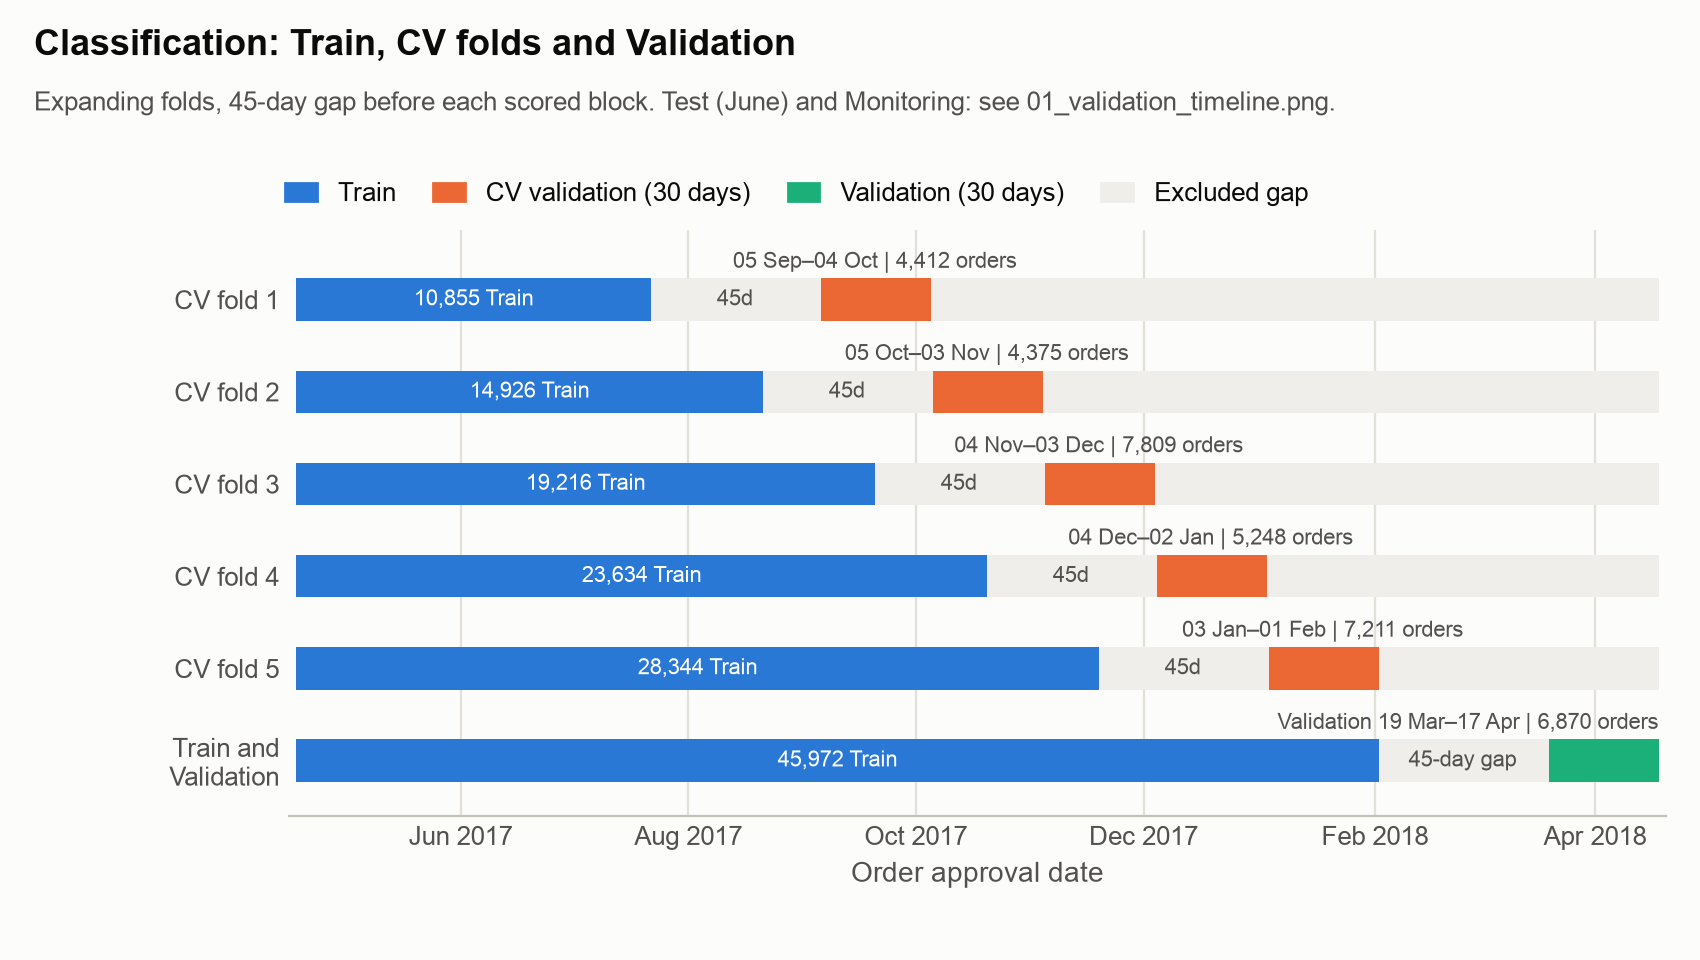

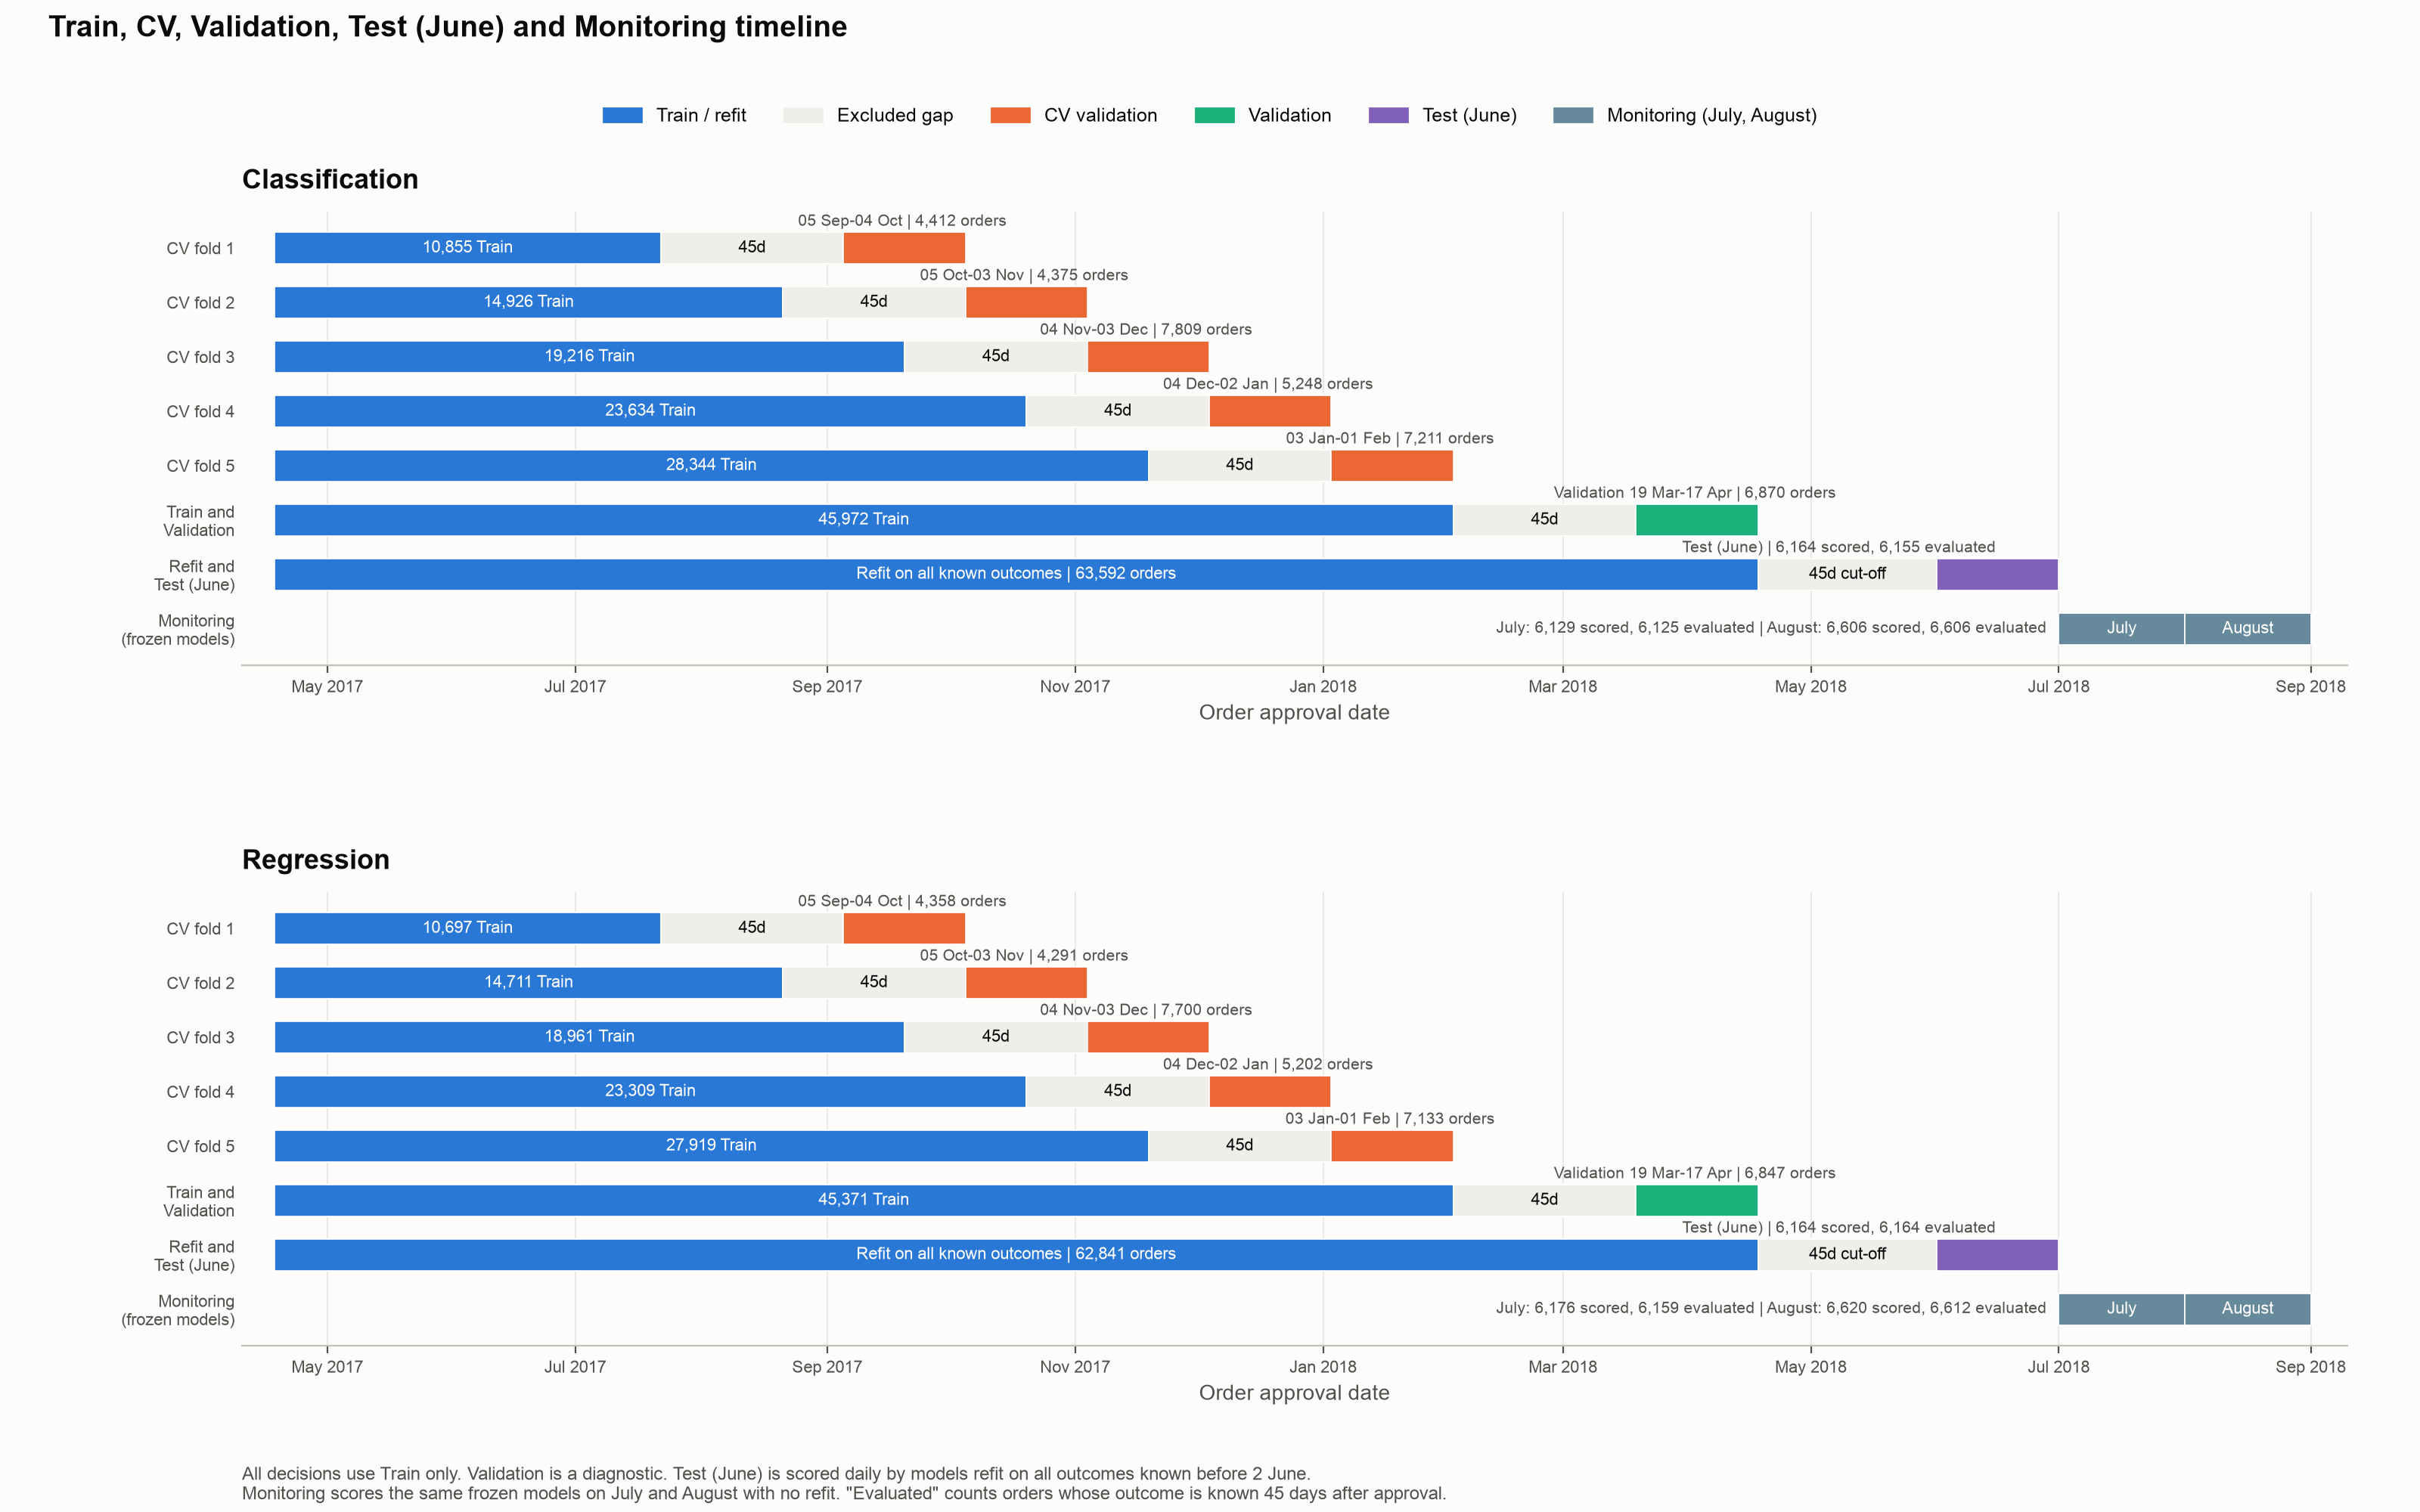

In [4]:
display(Image(Path('results/simple_to_complex/figures/01_cv_folds_classification.png'), width=900))
display(Image(Path('results/simple_to_complex/figures/01_validation_timeline.png'), width=1100))

## 3. C0: no-skill baseline

`DummyClassifier(strategy='prior')` predicts the Train late rate for every order. Its average precision equals the late rate of the cohort and its top-10% lift is about 1, so it is the floor every other model has to beat.

In [5]:
c0 = DummyClassifier(strategy='prior').fit(data.X_train, data.y_train)
print(f'C0 predicts {ev.late_probability(c0, data.X_train.head(1))[0]:.4f} for every order (Train late rate {data.y_train.mean():.4f})')

C0 predicts 0.0883 for every order (Train late rate 0.0883)


## 4. Stage 1: plain linear models

### 4.1 Quasi-separation and the route-type merge

In Train, the 118 orders with `route_type == '3. Mixed'` and the 227 orders with `seller_state_count >= 2` contain **no late orders**. An unpenalised logistic model cannot estimate a finite coefficient for a level with zero events (quasi-separation), so its estimate runs towards minus infinity and its standard error explodes. Every logistic model here therefore passes `merge_mixed_route=True`, which folds `3. Mixed` into `1. All interstate` (every mixed-route order has at least one interstate leg). `seller_state_count` stays in the feature set; where its coefficient is not identified, the coefficient tables flag it ("not identified (quasi-separation: no late orders among multi-state-seller orders)") instead of dropping the feature silently. The Random Forest uses the raw 24 features unchanged.

### 4.2 Transformations (pre-specified, linear models only)

The linear models always use the same transformations, fixed before any model is fitted from the predictors' distributions and the cyclic nature of month and weekday. They are not tuned on the outcome: variable selection (sections 4.4 to 4.6) is the only outcome-driven step. Trees are invariant to monotone transforms, so the Random Forest does not need any of this.

- **log1p on the 8 skewed inputs** (money, size, time and load variables). They are non-negative with long right tails (|skew| from 1.7 to 11.2 on Train, table above). log1p compresses the tail so a few extreme orders do not dominate a linear fit, handles zeros, and turns effects into per-doubling (multiplicative) terms that are easy to read. The choice used only the predictors' distribution on Train, never the outcome, so it adds no selection optimism; pre-specifying transformations is recommended by Harrell, *Regression Modeling Strategies*.
- **Sine and cosine for month and weekday.** They are cyclic: December is next to January and Sunday next to Monday, whereas a plain number imposes a false straight-line order and a jump at the wrap-around. Dummies would be exactly collinear with the weekend and December flags, and a sine/cosine pair captures a smooth seasonal cycle in two columns.
- **No squared terms.** Choosing polynomial terms by looking at the outcome would be another data-driven selection step; keeping variable selection as the only outcome-driven step keeps the method simple and avoids extra optimism. Each coefficient stays a single, interpretable slope, and any remaining nonlinearity is what the Random Forest stage tests, so the linear-versus-Random-Forest comparison is where nonlinearity is judged.
- **Why not other transformations?**
  - *Exponential and other expanding transforms (squares, powers above 1).* The skewed inputs already have long right tails; an expanding transform stretches the tail further and gives a few extreme orders even more leverage in a linear fit, the opposite of what is needed. It is also numerically unstable on money and volume values (exp of a payment value overflows).
  - *Quadratic and polynomial terms.* Choosing curvature terms by looking at the outcome is a second outcome-driven selection step, which adds optimism (specification search). The curvature diagnostic shows no strong curvature remains, and any remaining nonlinearity is tested by the Random Forest stage.
  - *Box-Cox and Yeo-Johnson.* These estimate a power per feature from the data. log1p is the simplest member of that family (Box-Cox lambda = 0, shifted by 1 to handle zeros) and gives readable "per doubling" effects. Fitting a lambda per feature adds parameters and makes coefficients harder to interpret, for little expected gain once the log has already reduced the skew.
  - *Splines and binning.* These are flexible, outcome-shaped terms. Flexible nonlinearity is exactly what the Random Forest stage is for, so the linear stage stays a simple, interpretable baseline.
  - *Principle.* Transformations are chosen from each input's distribution and for interpretability, not by searching over transformation families against the outcome, so variable selection remains the only outcome-driven step.

In [6]:
SKEW_CANDIDATES = ['payment_value_sum', 'order_frieght_value_sum', 'order_product_weight_g_sum',
                   'order_product_volume_cm3_sum', 'approval_lag_hours', 'seller_dist_km_mean',
                   'freight_to_price_ratio', 'orders_approved_prev_7d']
skew = skewness_table(data.train_df, SKEW_CANDIDATES)
LOG_COLS = skew.loc[skew['log1p_recommended'], 'feature'].tolist()
skew.round(2).to_csv(OUT / 'skewness_train.csv', index=False)
display(skew.round(2))

,feature,min,skew_raw,skew_log1p,non_negative,log1p_recommended
0,payment_value_sum,10.07,11.16,0.56,True,True
1,order_frieght_value_sum,0.00,8.99,1.19,True,True
2,order_product_weight_g_sum,0.00,6.70,0.38,True,True
3,order_product_volume_cm3_sum,288.00,8.22,-0.04,True,True
4,approval_lag_hours,0.09,4.61,0.97,True,True
5,seller_dist_km_mean,0.00,1.69,-1.10,True,True
6,freight_to_price_ratio,0.00,5.01,1.93,True,True
7,orders_approved_prev_7d,417.00,1.73,0.68,True,True


In [7]:
LINEAR_OPTIONS = dict(log_cols=LOG_COLS, cyclic=True, merge_mixed_route=True)


def build_logistic(units=FEATURES):
    """Unfitted plain logistic pipeline on `units` with the pre-specified linear design."""
    return make_unit_pipeline_builder(TASK, data.num_cols, data.cat_cols, **LINEAR_OPTIONS)(units)

### Curvature check (diagnostic only)

Binned partial residuals for the three strongest numeric predictors (largest |z| in a statsmodels logit on the pre-specified design, numeric columns with at least 20 distinct values). A straight line through the bin means supports a linear term. The plot is a diagnostic only: it does not change the design, and no squared terms are added. The promised-lead-days bins bend slightly at the extremes (a little above the line for the shortest promises, flat for the longest) and the other two panels scatter around the line without a consistent curve. The departures are small relative to the bin noise, so there is no strong curvature to justify extra terms; any remaining nonlinearity is left to the Random Forest comparison.

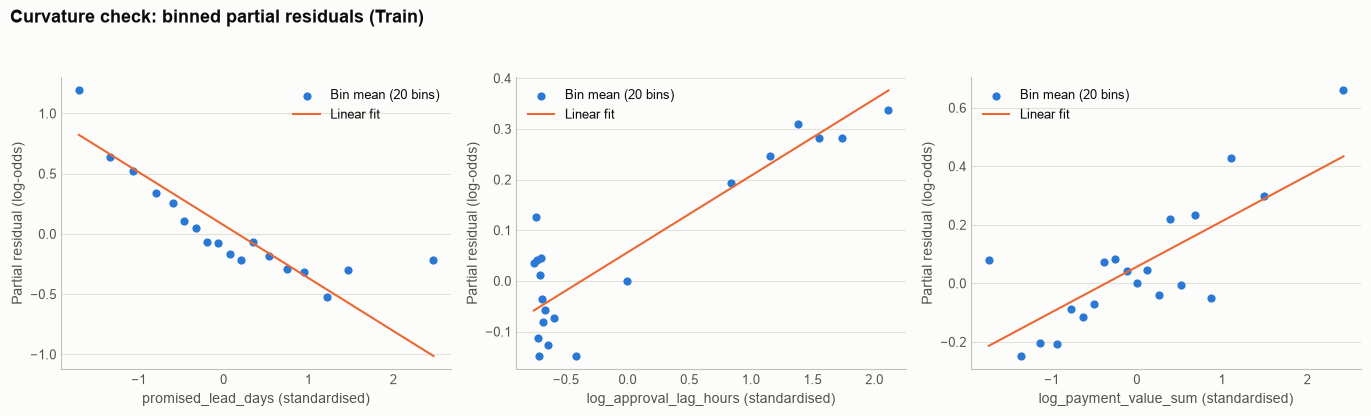

In [8]:
design, _, pre = linear_design(data.train_df, data.num_cols, data.cat_cols, **LINEAR_OPTIONS)
sm_probe = fit_statsmodels(TASK, design, data.y_train)
probe = coefficient_table(sm_probe, TASK, pre, data.cat_cols)
continuous = [c for c in data.num_cols if data.X_train[c].nunique() >= 20]  # enough values for 20 bins
numeric_terms = probe[probe['kind'].isin(['numeric', 'log']) & probe['unit'].isin(continuous)]
top_terms = numeric_terms.assign(abs_z=numeric_terms['statistic'].abs()).nlargest(3, 'abs_z')
mf.plot_partial_residuals(sm_probe, design, data.y_train, top_terms['term'].tolist(),
                          FIG / '02_curvature_partial_residuals.png')
plt.show()

In [9]:
numeric_design = design[[c for c in design.columns if design[c].nunique() > 2]]
linear_vif = numeric_vif(numeric_design).rename('vif').reset_index().rename(columns={'index': 'column'})
linear_vif.sort_values('vif', ascending=False).to_csv(OUT / 'linear_design_vif.csv', index=False)
display(linear_vif.sort_values('vif', ascending=False).head(8).round(2))

,column,vif
7,log_order_frieght_value_sum,6.01
12,log_payment_value_sum,5.87
17,log_freight_to_price_ratio,3.99
8,log_order_product_weight_g_sum,3.32
15,log_order_product_volume_cm3_sum,2.53
6,order_seller_count,2.29
10,log_seller_dist_km_mean,2.19
4,order_approved_month_cos,2.12


**Variance inflation on the final design.** The table lists the largest VIFs among numeric columns of the final linear design. Sine and cosine terms are paired by construction, so any high value should be read together with its partner column.

### 4.3 C1: plain logistic on all 24 features

Unpenalised, unweighted logistic regression (lbfgs, tolerance 1e-8) on the pre-specified transformations. CV here is not tuning: it gives an honest estimate of out-of-time performance. Mean and SD are over the 5 chronological folds.

The class-weight sensitivity row refits C1 with `class_weight='balanced'` on the same folds. Weighting reweights the loss, so it should change the probability scale (Brier) far more than the ranking (AP, AUC, top-10% precision).

In [10]:
c1_spec = build_logistic()
c1_weighted_spec = clone(c1_spec).set_params(classifier__class_weight='balanced')
CV_COLUMNS = ev.CLASSIFICATION_CV_METRICS
sensitivity_folds = {name: ev.cv_classification_metrics(spec, data.X_train, data.y_train, data.folds)
                     for name, spec in [('unweighted', c1_spec), ("class_weight='balanced'", c1_weighted_spec)]}
class_weight_sensitivity = pd.DataFrame({
    name: {f'{m} mean +/- SD': f'{f[m].mean():.4f} +/- {f[m].std(ddof=1):.4f}' for m in CV_COLUMNS}
    for name, f in sensitivity_folds.items()}).T
class_weight_sensitivity = ml.add_model_columns(
    class_weight_sensitivity.rename_axis('Class weight').reset_index().assign(model='C1'))
class_weight_sensitivity.to_csv(OUT / 'class_weight_sensitivity.csv', index=False)
display(class_weight_sensitivity)

,Code,Model,Class weight,avg_precision mean +/- SD,roc_auc mean +/- SD,brier mean +/- SD,precision_top10 mean +/- SD,top10_capture mean +/- SD,top10_lift mean +/- SD
0,C1,Logistic (all),unweighted,0.1383 +/- 0.0261,0.6050 +/- 0.0356,0.0869 +/- 0.0290,0.1638 +/- 0.0252,0.1816 +/- 0.0435,1.8144 +/- 0.4331
1,C1,Logistic (all),class_weight='balanced',0.1371 +/- 0.0271,0.6073 +/- 0.0319,0.2850 +/- 0.0394,0.1610 +/- 0.0250,0.1791 +/- 0.0454,1.7890 +/- 0.4522


### 4.4 CV-stepwise selection with the 1-SE rule: C2

Forward selection from an intercept-only model. Each step tries every remaining raw feature (the three categoricals move as whole dummy blocks; transformed variants travel with their raw feature) and adds the one with the best mean chronological-CV AP. Every addition is judged on later, unseen time periods rather than on in-sample p-values, which limits the usual stepwise overfitting. The 1-SE rule then picks the smallest step whose mean CV AP is within one standard error of the best step.

In [11]:
build_units = make_unit_pipeline_builder(TASK, data.num_cols, data.cat_cols, **LINEAR_OPTIONS)
cv_path, cv_candidates = forward_stepwise_cv(
    data.train_df, data.y_train, FEATURES, build_units, data.folds, 'average_precision',
    data.train_ids, n_jobs=-1)
chosen_step, best_step = one_se_rule(cv_path)
C2_UNITS = units_through_step(cv_path, chosen_step)
cv_path.to_csv(OUT / 'stepwise_path.csv', index=False)
cv_candidates.to_csv(OUT / 'stepwise_candidates.csv', index=False)
print(f'Best CV step {best_step}; 1-SE step {chosen_step}; early stop: {cv_path.attrs["stopped_early_after_step"]}')
print('C2 units in order of entry:', C2_UNITS)
display(cv_path.round(4))

Best CV step 12; 1-SE step 3; early stop: None
C2 units in order of entry: ['customer_state', 'promised_lead_days', 'route_type']


,step,added_unit,n_units,n_encoded_columns,cv_mean,cv_se
0,0,(intercept only),0,0,0.0957,0.0153
1,1,customer_state,1,26,0.1303,0.0174
2,2,promised_lead_days,2,27,0.1356,0.0165
3,3,route_type,3,28,0.1503,0.0158
4,4,order_product_weight_g_sum,4,29,0.1524,0.0160
5,5,order_seller_count,5,30,0.1542,0.0160
6,6,order_approved_day_of_month,6,31,0.1553,0.0170
7,7,approval_lag_hours,7,32,0.1560,0.0167
8,8,payment_combination,8,36,0.1564,0.0166
9,9,order_approved_day_of_week,9,38,0.1567,0.0168


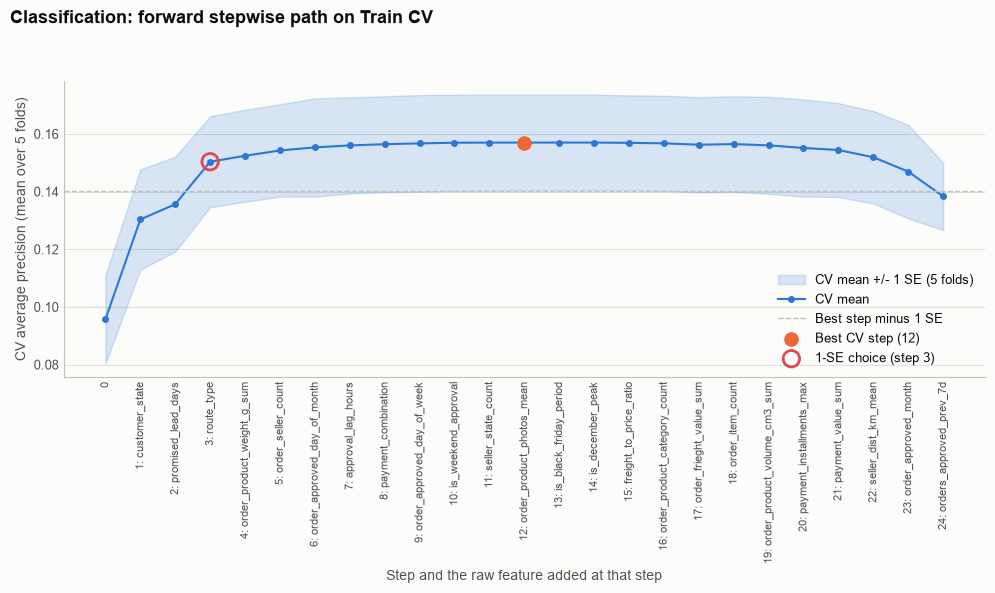

In [12]:
mf.plot_stepwise_path(cv_path, chosen_step, best_step, 'CV average precision (mean over 5 folds)',
                      FIG / '02_stepwise_path.png',
                      title='Classification: forward stepwise path on Train CV')
plt.show()

### 4.5 Information-criterion cross-check: C2B

The same forward procedure, but each candidate is scored in-sample on Train by BIC (stop when no addition lowers it) with statsmodels `Logit`; AIC is also run and only its selected set is reported. This is the classical, likelihood-based approach: fast, no folds, but it assumes independent rows and a stable relationship over time. Agreement with CV-stepwise is evidence of robustness. Candidates whose Newton fit fails (quasi-separation) are retried with BFGS and logged if still skipped.

In [13]:
def design_builder(rows):
    design, unit_columns, _ = linear_design(rows, data.num_cols, data.cat_cols, **LINEAR_OPTIONS)
    return design, unit_columns


bic_path, BIC_UNITS = forward_stepwise_ic(data.train_df, data.y_train, FEATURES, design_builder, TASK,
                                          data.train_ids, criterion='bic')
aic_path, AIC_UNITS = forward_stepwise_ic(data.train_df, data.y_train, FEATURES, design_builder, TASK,
                                          data.train_ids, criterion='aic')
bic_path.to_csv(OUT / 'ic_path_bic.csv', index=False)
aic_path.to_csv(OUT / 'ic_path_aic.csv', index=False)
print('BIC units:', BIC_UNITS)
print('AIC units:', AIC_UNITS)
print('Skipped candidates (BIC):', len(bic_path.attrs['skipped']), '| (AIC):', len(aic_path.attrs['skipped']))
display(bic_path.round(1))

BIC units: ['is_black_friday_period', 'customer_state', 'route_type', 'promised_lead_days', 'order_approved_month', 'order_seller_count', 'payment_value_sum', 'approval_lag_hours', 'is_december_peak', 'order_item_count', 'order_product_volume_cm3_sum', 'orders_approved_prev_7d']
AIC units: ['customer_state', 'is_black_friday_period', 'route_type', 'promised_lead_days', 'order_approved_month', 'order_seller_count', 'payment_value_sum', 'approval_lag_hours', 'is_december_peak', 'order_item_count', 'order_product_volume_cm3_sum', 'orders_approved_prev_7d', 'order_product_photos_mean', 'seller_state_count', 'payment_combination', 'seller_dist_km_mean', 'order_approved_day_of_week', 'is_weekend_approval', 'order_approved_day_of_month']
Skipped candidates (BIC): 0 | (AIC): 0


,step,added_unit,k,aic,bic,method
0,0,(intercept only),0,27463.1,27471.8,newton
1,1,is_black_friday_period,1,26960.1,26977.5,newton
2,2,customer_state,27,26362.1,26606.7,newton
3,3,route_type,28,26262.7,26516.0,newton
4,4,promised_lead_days,29,26132.6,26394.7,newton
5,5,order_approved_month,31,25967.2,26246.7,newton
6,6,order_seller_count,32,25907.4,26195.7,newton
7,7,payment_value_sum,33,25840.5,26137.5,newton
8,8,approval_lag_hours,34,25797.6,26103.3,newton
9,9,is_december_peak,35,25759.6,26074.1,newton


### 4.6 Lasso cross-check and the overlap table

L1-penalised logistic regression on the same design and folds, with the penalty chosen by mean CV AP over the default grid. A categorical block is kept if any of its dummies is non-zero. Lasso adds a column to the overlap table only; it gets no model row.

In [14]:
lasso = lasso_units(data.train_df, data.y_train, FEATURES, design_builder, TASK, data.folds, data.train_ids)
overlap = selection_overlap(FEATURES, cv_path, chosen_step, BIC_UNITS, AIC_UNITS, lasso['selected_units'])
overlap.to_csv(OUT / 'selection_overlap.csv', index=False)
print(f"Lasso penalty C = {lasso['penalty']:.4g}; {len(lasso['selected_units'])} units kept")
display(overlap)

Lasso penalty C = 166.8; 24 units kept


,unit,cv_stepwise,cv_step_entered,bic,aic,lasso,n_methods
0,customer_state,True,1,True,True,True,4
1,promised_lead_days,True,2,True,True,True,4
2,route_type,True,3,True,True,True,4
3,order_seller_count,False,5,True,True,True,3
4,approval_lag_hours,False,7,True,True,True,3
5,is_black_friday_period,False,13,True,True,True,3
6,is_december_peak,False,14,True,True,True,3
7,order_item_count,False,18,True,True,True,3
8,order_product_volume_cm3_sum,False,19,True,True,True,3
9,payment_value_sum,False,21,True,True,True,3


### 4.7 Model key

Every model in this notebook, with the number of raw features it uses. The linear subsets are the selections above; the Random Forests use all raw features.

In [15]:
n_features = {'C1': len(FEATURES), 'C2': len(C2_UNITS), 'C2B': len(BIC_UNITS), 'C3': len(FEATURES), 'C3d': len(FEATURES)}
display(ml.model_key_table(ml.CLASSIFICATION_CODES, n_features))

,Code,Model,Description,Features
0,C0,No-skill baseline,Predicts the Train late rate for every order,-
1,C1,Logistic (all),"Plain logistic regression, all 24 features, pr...",24
2,C2,Logistic (CV-stepwise),"Plain logistic, features chosen by CV forward ...",3
3,C2B,Logistic (BIC),"Plain logistic, features chosen by BIC forward...",12
4,C3,Random Forest (tuned),"Random Forest, raw 24 features, hyperparameter...",24
5,C3d,Random Forest (default),"Random Forest, raw 24 features, scikit-learn d...",24


## 5. Class-imbalance experiment

Late orders are about 9% of Train. Does rebalancing help? On the same 5 chronological CV folds we compare four options for **C1** (plain logistic with the pre-specified transformations) and **C3** (Random Forest with the cached best parameters): no resampling (baseline), random undersampling, random oversampling and SMOTENC (SMOTE for mixed numeric and categorical data; the three 0/1 flags and three categoricals are treated as categorical). Resampling balances the classes 1:1 and happens **only inside each training fold** through an `imblearn` pipeline; validation folds, Validation, June and later months are never resampled (tested in `test_resampling.py`). The final models do not use resampling.

Literature expectation: resampling does not improve ranking metrics (AP, AUC) and distorts calibration, so Brier gets worse (van den Goorbergh et al., 2022, "The harm of class imbalance corrections for risk prediction models", JAMIA 29(9):1525-1534; Chawla et al., 2002, SMOTE, JAIR 16:321-357). The cached Random Forest parameters are loaded here and presented in Stage 2.

In [16]:
rf_search = load_or_run_rf_search(TASK, run=RUN_RF_SEARCH, data=data)
RF_PARAMS = rf_search['best_params']
c3_spec = tuned_rf_pipeline(TASK, RF_PARAMS, data.num_cols, data.cat_cols)
print('Cached C3 parameters:', RF_PARAMS)

Cached C3 parameters: {'min_samples_split': 50, 'max_samples': 0.7, 'criterion': 'entropy', 'class_weight': None, 'max_depth': 8, 'min_samples_leaf': 2, 'max_features': 'log2', 'n_estimators': 500}


In [17]:
flags = rs.binary_columns(data.X_train, data.num_cols)
resampling_folds, resampling_summary, resampling_probs = rs.run_resampling_experiment(
    {'C1': c1_spec, 'C3': c3_spec}, data.X_train, data.y_train, data.folds,
    data.X_validation, data.y_validation, data.num_cols, data.cat_cols, flags)
resampling_folds.to_csv(OUT / 'resampling_cv_folds.csv', index=False)
resampling_summary.to_csv(OUT / 'resampling_summary.csv', index=False)


def mean_sd(row, metric, prefix='cv'):
    return f"{row[f'{prefix}_{metric}_mean']:.4f} +/- {row[f'{prefix}_{metric}_std']:.4f}"


resampling_table = ml.add_model_columns(pd.DataFrame([
    {'Model': r.model, 'Option': rs.STRATEGIES[r.strategy],
     'CV AP': mean_sd(r._asdict(), 'avg_precision'), 'CV ROC-AUC': mean_sd(r._asdict(), 'roc_auc'),
     'CV Brier': mean_sd(r._asdict(), 'brier'), 'CV top-10% precision': mean_sd(r._asdict(), 'precision_top10'),
     'CV top-10% lift': mean_sd(r._asdict(), 'top10_lift'),
     'Delta CV AP vs none (paired, +/- SE)': f'{r.ap_gain_vs_none:+.4f} +/- {r.ap_gain_se:.4f}',
     'Validation AP': round(r.val_avg_precision, 4), 'Validation ROC-AUC': round(r.val_roc_auc, 4),
     'Validation Brier': round(r.val_brier, 4), 'Validation top-10% precision': round(r.val_precision_top10, 4),
     'Validation top-10% lift': round(r.val_top10_lift, 2),
     'Validation mean predicted probability': round(r.val_mean_probability, 3)}
    for r in resampling_summary.itertuples()]), code_col='Model')
display(resampling_table)
print(f"Validation late rate: {resampling_summary['val_late_rate'].iloc[0]:.3f}")
print('Clear CV AP gain (> 2 paired SE) for any option:', bool(resampling_summary['clear_ap_gain'].any()))

,Code,Model,Option,CV AP,CV ROC-AUC,CV Brier,CV top-10% precision,CV top-10% lift,"Delta CV AP vs none (paired, +/- SE)",Validation AP,Validation ROC-AUC,Validation Brier,Validation top-10% precision,Validation top-10% lift,Validation mean predicted probability
0,C1,Logistic (all),No resampling,0.1383 +/- 0.0261,0.6050 +/- 0.0356,0.0869 +/- 0.0290,0.1638 +/- 0.0252,1.8144 +/- 0.4331,+0.0000 +/- 0.0000,0.2416,0.7209,0.0874,0.2984,2.88,0.096
1,C1,Logistic (all),Random undersampling,0.1298 +/- 0.0251,0.5951 +/- 0.0399,0.2642 +/- 0.0315,0.1524 +/- 0.0230,1.7090 +/- 0.5039,-0.0085 +/- 0.0012,0.2367,0.7174,0.2315,0.3130,3.02,0.479
2,C1,Logistic (all),Random oversampling,0.1345 +/- 0.0267,0.6015 +/- 0.0347,0.2800 +/- 0.0374,0.1601 +/- 0.0271,1.7704 +/- 0.4218,-0.0038 +/- 0.0014,0.2315,0.7153,0.2335,0.2868,2.76,0.481
3,C1,Logistic (all),SMOTENC,0.1312 +/- 0.0284,0.5855 +/- 0.0288,0.1046 +/- 0.0342,0.1469 +/- 0.0352,1.5801 +/- 0.1867,-0.0072 +/- 0.0081,0.1493,0.6121,0.2701,0.1718,1.65,0.485
4,C3,Random Forest (tuned),No resampling,0.2691 +/- 0.0370,0.6536 +/- 0.0223,0.0812 +/- 0.0292,0.2239 +/- 0.0337,2.4802 +/- 0.5902,+0.0000 +/- 0.0000,0.2194,0.7009,0.0905,0.2460,2.37,0.081
5,C3,Random Forest (tuned),Random undersampling,0.2668 +/- 0.0386,0.6522 +/- 0.0186,0.2279 +/- 0.0245,0.2255 +/- 0.0388,2.4766 +/- 0.5181,-0.0023 +/- 0.0044,0.2131,0.6934,0.2150,0.2242,2.16,0.459
6,C3,Random Forest (tuned),Random oversampling,0.2702 +/- 0.0397,0.6560 +/- 0.0193,0.2001 +/- 0.0211,0.2244 +/- 0.0459,2.4507 +/- 0.4848,+0.0011 +/- 0.0023,0.2155,0.6990,0.2056,0.2227,2.15,0.446
7,C3,Random Forest (tuned),SMOTENC,0.2316 +/- 0.0472,0.6131 +/- 0.0272,0.1347 +/- 0.0323,0.2084 +/- 0.0454,2.2735 +/- 0.5086,-0.0375 +/- 0.0125,0.1520,0.6253,0.1926,0.1863,1.80,0.412


Validation late rate: 0.104
Clear CV AP gain (> 2 paired SE) for any option: False


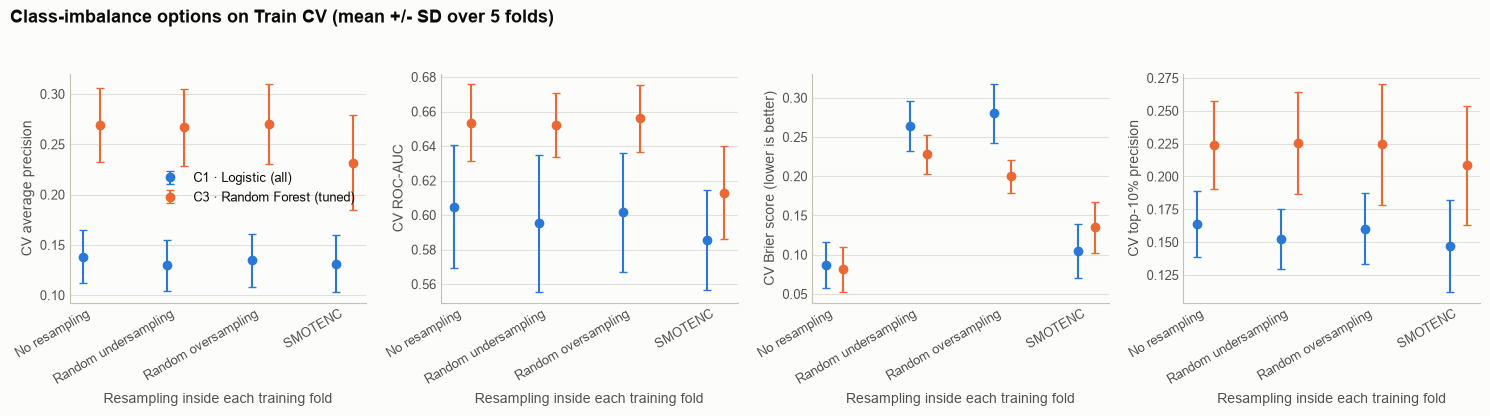

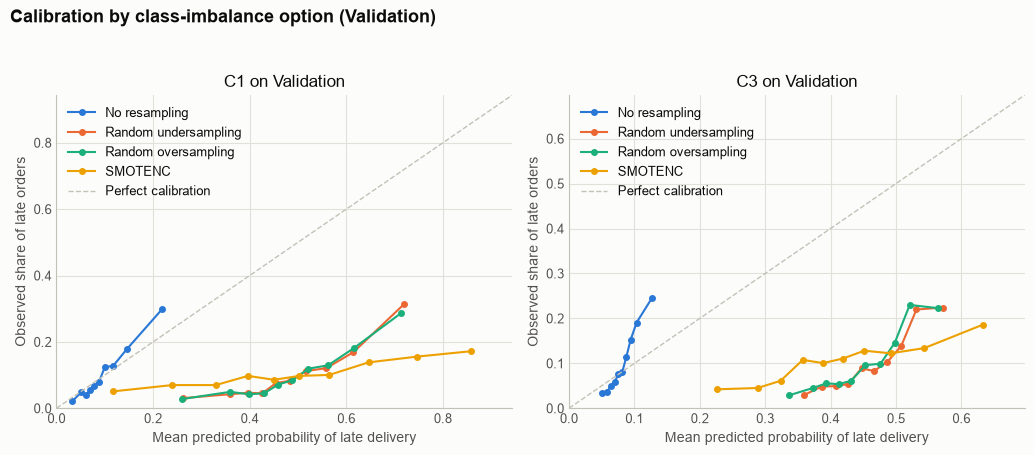

In [18]:
mf.plot_resampling_comparison(resampling_summary, rs.STRATEGIES, FIG / '02_resampling_cv_metrics.png',
                              title='Class-imbalance options on Train CV (mean +/- SD over 5 folds)')
plt.show()
panels = {f'{model} on Validation': {rs.STRATEGIES[s]: (data.y_validation, resampling_probs[(model, s)])
                                      for s in rs.STRATEGIES} for model in ['C1', 'C3']}
mf.plot_calibration(panels, FIG / '02_resampling_calibration.png',
                    title='Calibration by class-imbalance option (Validation)')
plt.show()

**What the experiment shows (numbers from the tables above).**
- **Ranking did not improve.** No resampling option clearly raised CV average precision (AP) for either model. For C1 all three options lowered CV AP (no resampling 0.138; undersampling 0.130, oversampling 0.135, SMOTENC 0.131; paired changes -0.009, -0.004 and -0.007). For C3 the baseline was 0.269; oversampling was +0.001 +/- 0.002 (noise), undersampling -0.002 and SMOTENC -0.038. ROC-AUC and top-10% precision and lift moved in the same direction, always within the fold-to-fold SD (about 0.02 to 0.05) except for SMOTENC, which was clearly worse.
- **Calibration was badly distorted.** CV Brier rose from 0.087 to 0.264 (undersampling), 0.280 (oversampling) and 0.105 (SMOTENC) for C1, and from 0.081 to 0.228, 0.200 and 0.135 for C3. On Validation the mean predicted late probability was about 0.48 for every resampled C1 against an observed late rate of 0.104 (baseline 0.096), so the predicted probabilities no longer mean what they say; the calibration figure shows the curves far to the right of the diagonal.
- **Decision.** No resampling option clearly improves CV AP, so none is adopted: **C1 to C3d are all fitted on the original class mix**, and the probabilities stay interpretable. This agrees with the literature expectation that imbalance corrections do not help ranking and harm calibration (van den Goorbergh et al., 2022; Chawla et al., 2002). Note that the cached C3 uses `class_weight=None`, so the baseline forest has no weighting that resampling would duplicate.

## 6. Stage 2: Random Forest

The forest works on the raw 24 features (no transformations) and tunes its own `class_weight`. The wide two-stage search (Stage A: 60 random candidates with 200 trees; Stage B: a neighbourhood grid around the Stage A best with 300 or 500 trees) was run once from `python -m src.rf_search` on Train with the same 5 folds, scored by AP. Ties go to the simpler forest. This notebook only loads the cached result.

**C3d** is the untuned baseline: `RandomForestClassifier(random_state=42, n_jobs=-1)` with scikit-learn defaults, on the same raw features and reference-coded preprocessor. The defaults are 100 trees, fully grown trees (`max_depth=None`, `min_samples_leaf=1`, `min_samples_split=2`), `max_features='sqrt'`, `criterion='gini'`, `class_weight=None` and bootstrap sampling with full-size samples. The comparison of C3 with C3d shows what tuning buys.

In [19]:
meta = rf_search['metadata']
space = pd.DataFrame({'parameter': list(search_space(TASK)),
                      'values searched (Stage A)': [', '.join(map(str, v)) for v in search_space(TASK).values()]})
summary = pd.DataFrame([
    ('Stage A candidates', meta['n_iter_stage_a']), ('Stage A trees', meta['stage_a_trees']),
    ('Stage B candidates', meta['stage_b_candidates']), ('Stage B trees', ' or '.join(map(str, meta['stage_b_trees']))),
    ('Best CV AP (mean +/- SD)', f"{meta['best_cv_mean']:.4f} +/- {meta['best_cv_sd']:.4f}"),
    ('Stage A best CV AP', f"{meta['stage_a_best_cv_mean']:.4f}"),
    ('Search time (Stage A + B, s)', round(meta['stage_a_seconds'] + meta['stage_b_seconds'])),
    ('Best parameters', json.dumps(RF_PARAMS))], columns=['Item', 'Value'])
top_candidates = rf_search['stage_b'].head(5).round(4)
display(space)
display(summary)
display(top_candidates)

,parameter,values searched (Stage A)
0,max_depth,"None, 6, 8, 10, 12, 16, 20, 30"
1,min_samples_leaf,"1, 2, 5, 10, 20, 50, 100, 200"
2,min_samples_split,"2, 5, 10, 20, 50"
3,max_features,"log2, sqrt, 0.2, 0.3, 0.5, 0.7, 1.0"
4,max_samples,"None, 0.5, 0.7, 0.9"
5,class_weight,"None, balanced, balanced_subsample"
6,criterion,"gini, entropy"


,Item,Value
0,Stage A candidates,60
1,Stage A trees,200
2,Stage B candidates,24
3,Stage B trees,300 or 500
4,Best CV AP (mean +/- SD),0.2691 +/- 0.0331
5,Stage A best CV AP,0.2657
6,"Search time (Stage A + B, s)",206
7,Best parameters,"{""min_samples_split"": 50, ""max_samples"": 0.7, ..."


,class_weight,criterion,max_depth,max_features,max_samples,min_samples_leaf,min_samples_split,n_estimators,mean_score,sd_score,mean_fit_time,mean_score_time,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score
0,NaN,entropy,8,log2,0.7,2,50,500,0.2691,0.0331,3.9767,0.1321,0.2775,0.3133,0.2925,0.2302,0.2318
1,NaN,entropy,8,log2,0.7,1,50,500,0.2685,0.0332,4.0024,0.1207,0.2751,0.3132,0.2924,0.2260,0.2357
2,NaN,entropy,10,log2,0.7,1,50,500,0.2683,0.0336,4.3130,0.1515,0.2697,0.3141,0.2957,0.2324,0.2294
3,NaN,entropy,10,log2,0.7,2,50,500,0.2678,0.0348,4.6221,0.1456,0.2700,0.3155,0.2955,0.2280,0.2299
4,NaN,entropy,10,log2,0.7,1,50,300,0.2677,0.0336,2.5247,0.0807,0.2665,0.3138,0.2962,0.2342,0.2278


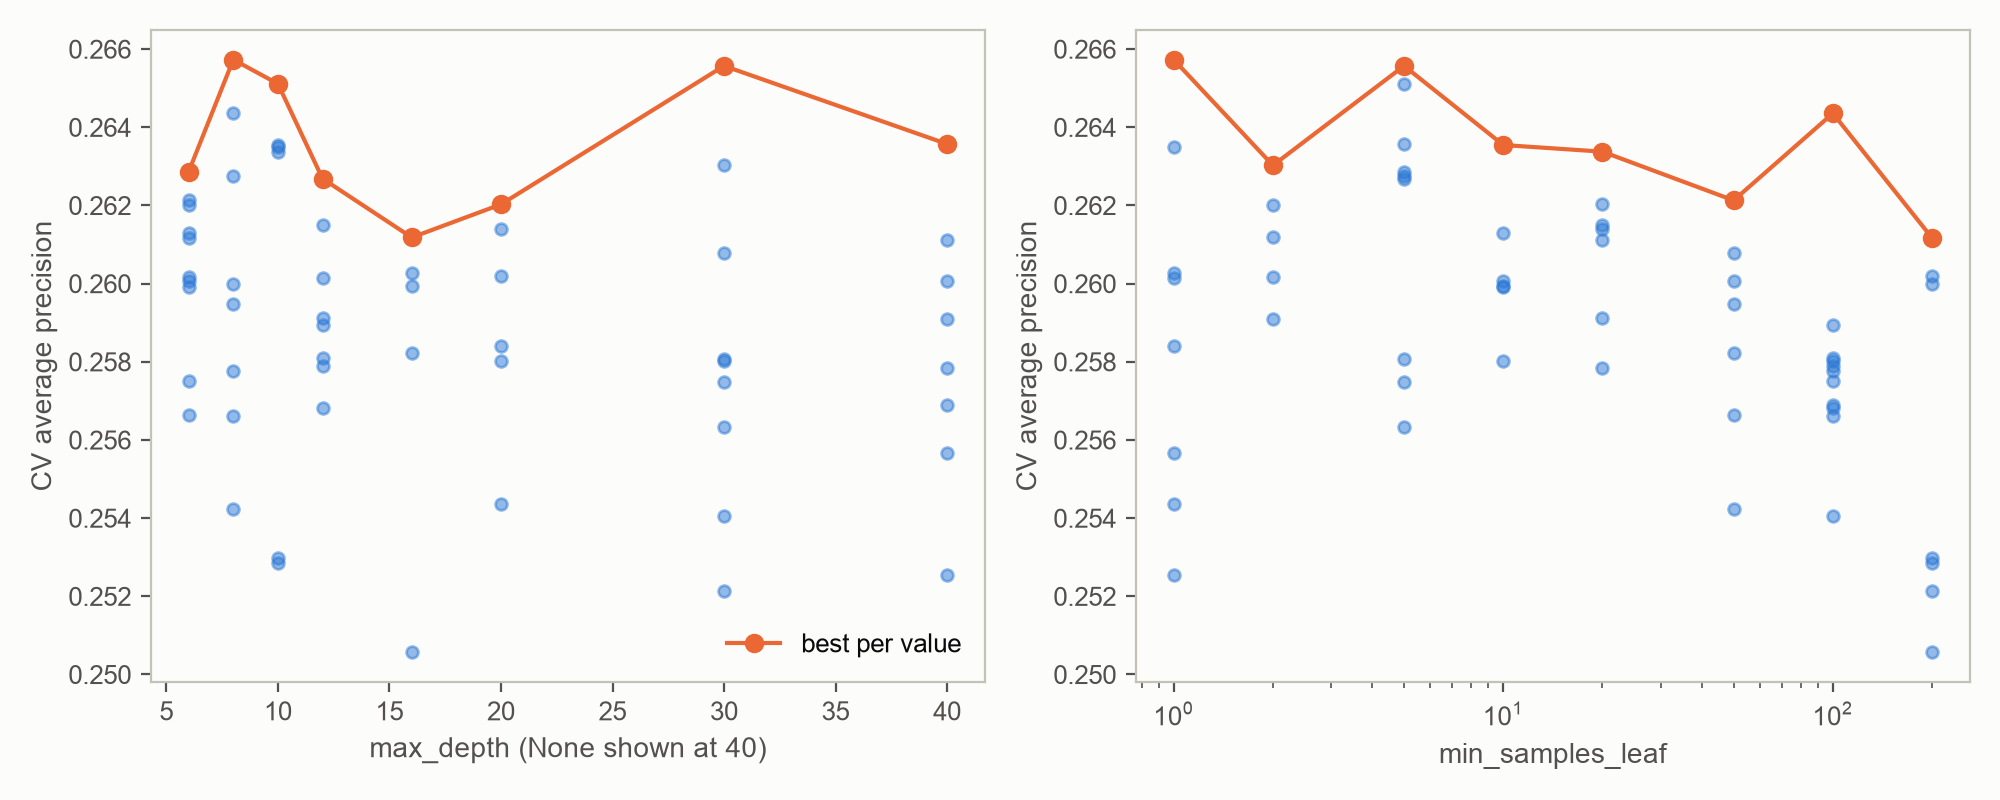

In [20]:
plot_rf_sensitivity(rf_search['stage_a'], TASK, FIG / '02_rf_sensitivity.png')
display(Image(FIG / '02_rf_sensitivity.png'))

**Reading the search.** The best forest is shallow and heavily regularised (depth 8, `min_samples_split` 50, `max_features='log2'`, 70% sub-samples, 500 trees, no class weighting), with CV AP 0.269 +/- 0.033. The sensitivity figure shows how CV AP varies with depth and leaf size across the Stage A candidates; the chosen settings are restrained, and the overfitting of an unrestrained forest is quantified for C3d below. Stage B moved the score only from 0.266 to 0.269, so the result is not sensitive to fine tuning.

## 7. Evaluation: Train, CV, Validation and the June refit

Every model uses the same procedure:
1. Fit on Train; score Train (in-sample) and Validation. Validation is for diagnostics only; no choice uses it.
2. Chronological CV on Train (mean and SD over 5 folds).
3. Refit the **fixed specification** (same transformations, same selected variables, same forest parameters) on the full known-outcome history before 2 June, then score June daily with `run_inference` and pool the daily scores before computing metrics.

Top-10% metrics use the highest-scored 10% of all scored orders (operational capacity); lift is the share of late orders captured divided by 10%.

In [21]:
rf_default_spec = Pipeline([
    ('preprocessor', make_preprocessor(data.num_cols, data.cat_cols, reference_categories=True)),
    ('classifier', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))])
SPECS = {'C0': DummyClassifier(strategy='prior'),
         'C1': c1_spec,
         'C2': build_units(C2_UNITS),
         'C2B': build_units(BIC_UNITS),
         'C3': c3_spec,
         'C3d': rf_default_spec}
LINEAR = ['C1', 'C2', 'C2B']


def fit_spec(label, X, y):
    """Fit one specification; plain logistic falls back to a negligible L2 only if lbfgs fails."""
    if label in LINEAR:
        return fit_logistic_checked(SPECS[label], X, y)
    return clone(SPECS[label]).fit(X, y), {'converged': True, 'fallback': None}

In [22]:
train_fits, convergence, result_rows, cv_parts = {}, {}, [], []
validation_probs = {}
for label in SPECS:
    fitted, convergence[label] = fit_spec(label, data.X_train, data.y_train)
    train_fits[label] = fitted
    validation_probs[label] = ev.late_probability(fitted, data.X_validation)
    result_rows.append(ev.score_split(label, 'Train', data.y_train, ev.late_probability(fitted, data.X_train),
                                      data.train_df['order_id']))
    result_rows.append(ev.score_split(label, 'Validation', data.y_validation, validation_probs[label],
                                      data.validation_df['order_id']))
    cv_parts.append(ev.cv_classification_metrics(SPECS[label], data.X_train, data.y_train, data.folds)
                    .assign(model=label))
cv_folds = pd.concat(cv_parts, ignore_index=True)
print({label: info['converged'] for label, info in convergence.items()})

{'C0': True, 'C1': True, 'C2': True, 'C2B': True, 'C3': True, 'C3d': True}


In [23]:
history = data.history_df
june_fits, june_scored, fingerprints = {}, {}, {}
for label in SPECS:
    june_fits[label], _ = fit_spec(label, history[FEATURES], history['y'])
    fingerprints[label] = {'before_june': ev.fingerprint(june_fits[label])}
    june_scored[label] = ev.score_months(june_fits[label], final_df, orders, FEATURES, ['2018-06'])['2018-06']

june_ids = june_scored['C0']['order_id'].tolist()
june_labels = june_scored['C0']['actual_label']
for label, frame in june_scored.items():
    assert frame['order_id'].tolist() == june_ids, f'{label} scored different June orders'
    assert frame['actual_label'].equals(june_labels), f'{label} received different June labels'
assert not set(june_ids) & set(history['order_id']), 'June orders leaked into the history'
for label, frame in june_scored.items():
    result_rows.append(ev.score_split(label, 'June', frame['actual_label'], frame['predicted_probability'],
                                      frame['order_id']))
june_summary = pd.Series({'scored orders': len(june_ids), 'known outcomes': int(june_labels.notna().sum()),
                          'late orders': int(june_labels.fillna(0).sum())})
display(june_summary.to_frame('June (Test)').T)

,scored orders,known outcomes,late orders
June (Test),6164,6155,137


## 8. Freeze and monitor: July and August

Each June-fitted model is frozen: its learned state is hashed (SHA-256 fingerprint) before and after scoring, and the fingerprints must be identical across June, July and August (no refit, retune, reselection or re-transformation). July and August are Monitoring months scored by the same frozen models.

In [24]:
monitoring = {}
for label, fitted in june_fits.items():
    monitoring[label] = ev.score_months(fitted, final_df, orders, FEATURES, ['2018-07', '2018-08'])
    fingerprints[label]['after_august'] = ev.fingerprint(fitted)
    assert fingerprints[label]['before_june'] == fingerprints[label]['after_august'], f'{label} changed'
    for month, name in [('2018-07', 'July'), ('2018-08', 'August')]:
        frame = monitoring[label][month]
        result_rows.append(ev.score_split(label, name, frame['actual_label'], frame['predicted_probability'],
                                          frame['order_id']))
results = pd.DataFrame(result_rows)
results['model'] = pd.Categorical(results['model'], list(SPECS)).astype(str)
results.to_csv(OUT / 'model_results_long.csv', index=False)
cv_folds.to_csv(OUT / 'cv_fold_scores.csv', index=False)
fingerprint_table = pd.DataFrame({label: {'fingerprint': f['before_june'][:16], 'unchanged after August': f['before_june'] == f['after_august']}
                                  for label, f in fingerprints.items()}).T
display(ml.add_model_columns(fingerprint_table.rename_axis('model').reset_index()))

,Code,Model,fingerprint,unchanged after August
0,C0,No-skill baseline,6cfc3554829e5180,True
1,C1,Logistic (all),972d0be17c116ed5,True
2,C2,Logistic (CV-stepwise),de15893361fa08f6,True
3,C2B,Logistic (BIC),48611cc50693dfef,True
4,C3,Random Forest (tuned),9f7b8ab14796ecdd,True
5,C3d,Random Forest (default),80cab31f8d470b89,True


## 9. Results

### 9.1 Full model comparison

Columns: Train (in-sample), CV mean +/- SD over 5 chronological folds, Validation, **June (Test, headline)**, and July and August (Monitoring). The late rate differs by split, so compare models within a column. AP and top-10% precision are in percent.

In [25]:
METRICS = [('avg_precision', 'Average precision (%)', True), ('roc_auc', 'ROC-AUC', False),
           ('brier', 'Brier score (lower is better)', False), ('precision_top10', 'Top-10% precision (%)', True),
           ('top10_capture', 'Top-10% capture of late orders', False), ('top10_lift', 'Top-10% lift', False)]
comparison_tables = {title: ml.add_model_columns(ev.comparison_table(results, cv_folds, metric, percent=percent), code_col='Model')
                     for metric, title, percent in METRICS}
for title, table in comparison_tables.items():
    print(title)
    display(table)
late_rates = results.pivot(index='model', columns='split', values='late_rate').loc[:, ['Train', 'Validation', 'June', 'July', 'August']].iloc[[0]].round(4)
display(late_rates.rename(index={'C0': 'Late rate of scored cohort'}))

Average precision (%)


,Code,Model,Train,CV mean +/- SD,Validation,June,July,August
0,C0,No-skill baseline,8.83,9.57 +/- 3.43,10.38,2.23,5.19,7.92
1,C1,Logistic (all),21.17,13.83 +/- 2.61,24.16,8.06,8.65,11.98
2,C2,Logistic (CV-stepwise),15.16,15.03 +/- 3.52,23.64,7.32,9.30,11.55
3,C2B,Logistic (BIC),20.87,14.15 +/- 2.60,24.04,8.03,9.00,12.79
4,C3,Random Forest (tuned),39.80,26.91 +/- 3.70,21.94,11.22,11.18,11.37
5,C3d,Random Forest (default),100.00,25.26 +/- 4.00,20.38,10.97,12.22,11.59


ROC-AUC


,Code,Model,Train,CV mean +/- SD,Validation,June,July,August
0,C0,No-skill baseline,0.500,0.500 +/- 0.000,0.500,0.500,0.500,0.500
1,C1,Logistic (all),0.686,0.605 +/- 0.036,0.721,0.692,0.576,0.573
2,C2,Logistic (CV-stepwise),0.640,0.613 +/- 0.022,0.701,0.694,0.568,0.577
3,C2B,Logistic (BIC),0.684,0.607 +/- 0.035,0.719,0.698,0.578,0.603
4,C3,Random Forest (tuned),0.778,0.654 +/- 0.022,0.701,0.637,0.544,0.426
5,C3d,Random Forest (default),1.000,0.625 +/- 0.026,0.669,0.653,0.591,0.530


Brier score (lower is better)


...

Top-10% capture of late orders


,Code,Model,Train,CV mean +/- SD,Validation,June,July,August
0,C0,No-skill baseline,0.093,0.096 +/- 0.044,0.093,0.066,0.082,0.099
1,C1,Logistic (all),0.291,0.182 +/- 0.043,0.288,0.328,0.192,0.155
2,C2,Logistic (CV-stepwise),0.208,0.193 +/- 0.052,0.289,0.321,0.192,0.155
3,C2B,Logistic (BIC),0.287,0.192 +/- 0.056,0.293,0.321,0.189,0.164
4,C3,Random Forest (tuned),0.390,0.248 +/- 0.059,0.237,0.328,0.173,0.134
5,C3d,Random Forest (default),1.000,0.230 +/- 0.035,0.227,0.314,0.201,0.120


Top-10% lift


,Code,Model,Train,CV mean +/- SD,Validation,June,July,August
0,C0,No-skill baseline,0.931,0.961 +/- 0.438,0.926,0.656,0.817,0.994
1,C1,Logistic (all),2.910,1.814 +/- 0.433,2.875,3.281,1.918,1.548
2,C2,Logistic (CV-stepwise),2.075,1.930 +/- 0.517,2.889,3.209,1.918,1.548
3,C2B,Logistic (BIC),2.873,1.918 +/- 0.553,2.931,3.209,1.886,1.643
4,C3,Random Forest (tuned),3.900,2.480 +/- 0.590,2.370,3.281,1.729,1.338
5,C3d,Random Forest (default),9.998,2.293 +/- 0.352,2.272,3.136,2.012,1.204


split,Train,Validation,June,July,August
model,,,,,
Late rate of scored cohort,0.0883,0.1038,0.0223,0.0519,0.0792


In [26]:
at_half = results.pivot(index='model', columns='split', values='precision_at_0_5')
recall_half = results.pivot(index='model', columns='split', values='recall_at_0_5')
threshold_table = pd.concat({'Precision at 0.5': at_half, 'Recall at 0.5': recall_half}, axis=1)[
    [(m, s) for m in ['Precision at 0.5', 'Recall at 0.5'] for s in ['Validation', 'June']]].round(3)
display(threshold_table)

Precision at 0.5      Recall at 0.5       
split       Validation June    Validation   June
model                                           
C0               0.000  0.0         0.000  0.000
C1               0.333  0.0         0.001  0.000
C2               0.000  0.0         0.000  0.000
C2B              1.000  0.0         0.001  0.000
C3               1.000  0.0         0.003  0.000
C3d              1.000  1.0         0.013  0.044

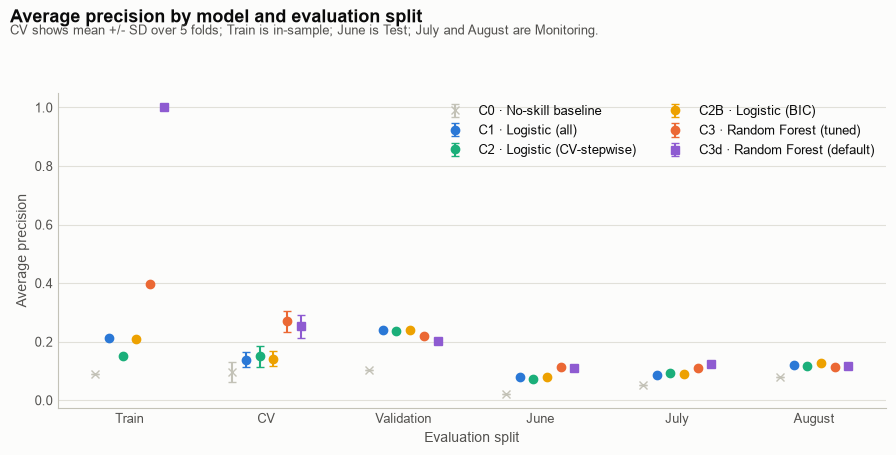

In [27]:
labels = list(SPECS)
cv_mean, cv_sd = ev.cv_mean_sd(cv_folds)
wide_ap = results.pivot(index='model', columns='split', values='avg_precision').loc[labels]
values = pd.concat([wide_ap[['Train']], cv_mean.loc[labels, ['avg_precision']].rename(columns={'avg_precision': 'CV'}),
                    wide_ap[['Validation', 'June', 'July', 'August']]], axis=1)
sds = pd.DataFrame(np.nan, index=values.index, columns=values.columns)
sds['CV'] = cv_sd.loc[labels, 'avg_precision']
mf.plot_model_comparison(values, 'Average precision', sds, FIG / '02_model_comparison_ap.png',
                         title='Average precision by model and evaluation split',
                         subtitle='CV shows mean +/- SD over 5 folds; Train is in-sample; June is Test; July and August are Monitoring.')
plt.show()

### 9.2 Success criteria and overfitting gaps

Criteria: top-10% lift of at least 2 for each model; the Random Forests' top-10% precision at least 1.10 times the better of the plain logistic models C1 and C2 on the same split. Overfitting gap = Train (in-sample) minus CV mean.

In [28]:
criteria = ev.classification_success_criteria(results, ['C1', 'C2'], ['C3', 'C3d'])
criteria_display = ml.add_model_columns(
    criteria.assign(value=criteria['value'].round(3), threshold=criteria['threshold'].round(3),
                    passed=criteria['passed'].map({True: 'pass', False: 'fail'})))
display(criteria_display)
gap_metrics = ['avg_precision', 'roc_auc', 'brier', 'precision_top10', 'top10_lift']
gaps = ml.add_model_columns(ev.overfitting_gaps(results, cv_folds, gap_metrics).round(4))
display(gaps)

,Code,Model,split,criterion,value,threshold,passed
0,C1,Logistic (all),June,Top-10% lift >= 2,3.281,2.00,pass
1,C2,Logistic (CV-stepwise),June,Top-10% lift >= 2,3.209,2.00,pass
2,C2B,Logistic (BIC),June,Top-10% lift >= 2,3.209,2.00,pass
3,C3,Random Forest (tuned),June,Top-10% lift >= 2,3.281,2.00,pass
4,C3d,Random Forest (default),June,Top-10% lift >= 2,3.136,2.00,pass
5,C3,Random Forest (tuned),June,Top-10% precision >= 1.1 x best linear (C1),0.073,0.08,fail
6,C3d,Random Forest (default),June,Top-10% precision >= 1.1 x best linear (C1),0.070,0.08,fail
7,C1,Logistic (all),Validation,Top-10% lift >= 2,2.875,2.00,pass
8,C2,Logistic (CV-stepwise),Validation,Top-10% lift >= 2,2.889,2.00,pass
9,C2B,Logistic (BIC),Validation,Top-10% lift >= 2,2.931,2.00,pass


,Code,Model,avg_precision,roc_auc,brier,precision_top10,top10_lift
0,C0,No-skill baseline,-0.0073,0.0000,-0.0067,-0.0066,-0.0303
1,C1,Logistic (all),0.0733,0.0813,-0.0108,0.0933,1.0957
2,C2,Logistic (CV-stepwise),0.0012,0.0266,-0.0078,0.0084,0.1456
3,C2B,Logistic (BIC),0.0672,0.0767,-0.0105,0.0829,0.9555
4,C3,Random Forest (tuned),0.1289,0.1240,-0.0106,0.1206,1.4196
5,C3d,Random Forest (default),0.7474,0.3754,-0.0698,0.6707,7.7052


### 9.3 June risk deciles: coverage, capture and lift

Scored June orders are ranked by predicted probability of lateness (decile 1 = riskiest). Capture is the share of all late orders that fall in each decile (cumulatively in the chart); lift is the decile's late rate relative to the overall late rate.

,C0 · No-skill baseline,C1 · Logistic (all),C2 · Logistic (CV-stepwise),C2B · Logistic (BIC),C3 · Random Forest (tuned),C3d · Random Forest (default)
Decile (cumulative capture %),,,,,,
1,6.6,32.8,32.1,32.1,32.8,31.4
2,15.3,49.6,46.7,51.8,47.4,42.3
3,29.9,59.9,59.1,59.9,55.5,50.4
4,40.1,65.0,65.7,65.7,57.7,61.3
5,50.4,70.1,73.7,70.1,64.2,69.3
6,55.5,80.3,81.8,78.1,67.9,76.6
7,67.2,85.4,86.1,86.9,70.8,83.2
8,75.9,93.4,92.7,94.2,85.4,88.3
9,86.1,98.5,97.1,99.3,92.7,94.9


,C0 · No-skill baseline,C1 · Logistic (all),C2 · Logistic (CV-stepwise),C2B · Logistic (BIC),C3 · Random Forest (tuned),C3d · Random Forest (default)
Decile (lift),,,,,,
1,0.66,3.28,3.21,3.21,3.28,3.14
2,0.88,1.68,1.46,1.97,1.46,1.10
3,1.46,1.02,1.24,0.80,0.80,0.80
4,1.02,0.51,0.66,0.58,0.22,1.10
5,1.02,0.51,0.80,0.44,0.66,0.80
6,0.51,1.02,0.80,0.80,0.36,0.73
7,1.17,0.51,0.44,0.88,0.29,0.66
8,0.88,0.80,0.66,0.73,1.46,0.51
9,1.02,0.51,0.44,0.51,0.73,0.66


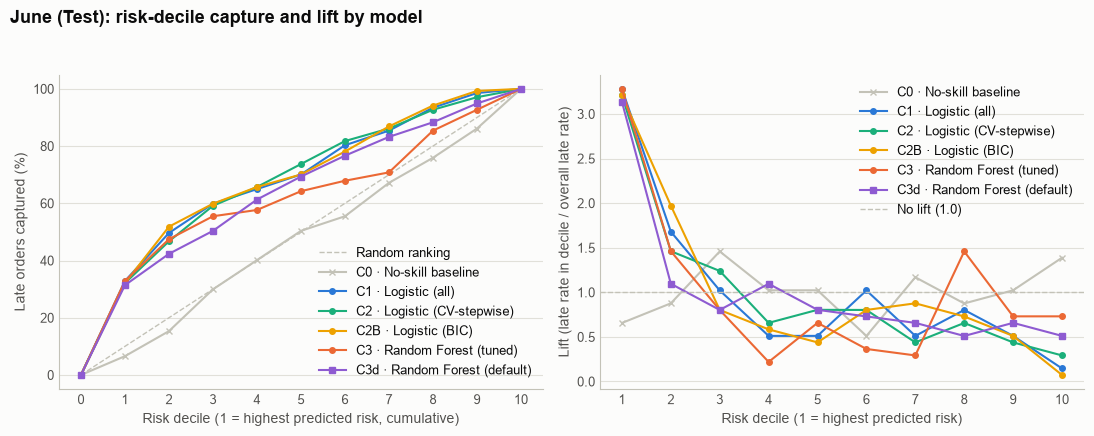

In [29]:
deciles = {label: ev.risk_decile_coverage(june_scored[label]) for label in SPECS}
capture = pd.DataFrame({label: t['cumulative_capture_pct'] for label, t in deciles.items()}).round(1)
lift_by_decile = pd.DataFrame({label: t['lift'] for label, t in deciles.items()}).round(2)
for table in (capture, lift_by_decile):
    table.index = pd.Index(range(1, 11), name='Decile')
display(ml.label_model_columns(capture.rename_axis('Decile (cumulative capture %)')))
display(ml.label_model_columns(lift_by_decile.rename_axis('Decile (lift)')))
mf.plot_decile_lift(deciles, FIG / '02_june_decile_lift.png',
                    title='June (Test): risk-decile capture and lift by model')
plt.show()

### 9.4 Does tuning the Random Forest help? C3 versus C3d

Tuned minus default for each metric on CV, Validation and June (positive is better except Brier, where negative is better), plus both forests' Train minus CV gaps.

In [30]:
tuning_gain = ev.tuning_gain_table(results, cv_folds, 'C3', 'C3d', gap_metrics)
display(tuning_gain.round(4))

,metric,CV: C3,CV: C3d,CV: gain,Validation: C3,Validation: C3d,Validation: gain,June: C3,June: C3d,June: gain,Train - CV gap: C3,Train - CV gap: C3d
0,avg_precision,0.2691,0.2526,0.0165,0.2194,0.2038,0.0156,0.1122,0.1097,0.0025,0.1289,0.7474
1,roc_auc,0.6536,0.6246,0.0290,0.7009,0.6686,0.0324,0.6369,0.6529,-0.0159,0.1240,0.3754
2,brier,0.0812,0.0794,0.0018,0.0905,0.0889,0.0017,0.0268,0.0266,0.0002,-0.0106,-0.0698
3,precision_top10,0.2239,0.2125,0.0114,0.2460,0.2358,0.0102,0.0729,0.0697,0.0032,0.1206,0.6707
4,top10_lift,2.4802,2.2930,0.1872,2.3703,2.2721,0.0982,3.2815,3.1356,0.1458,1.4196,7.7052


**What tuning bought.** The tuned forest C3 beats the default C3d on CV AP (0.269 versus 0.253, +0.017) and Validation AP (0.219 versus 0.204, +0.016), but on June the gain is negligible (AP 0.112 versus 0.110) and ROC-AUC is lower (0.637 versus 0.653). The main effect is on overfitting: the default forest memorises Train (in-sample AP 1.00, ROC-AUC 1.00, Train minus CV AP gap 0.75), while the tuned forest's gap is 0.13. Tuning therefore makes the model honest about its Train performance and modestly improves out-of-time CV and Validation ranking, but it does not produce a reliable June advantage.

### 9.5 Drift: June to July to August

The frozen models are scored on later months without refitting. The late rate also moves between months, so AP is read alongside the cohort late rate; ROC-AUC and top-10% lift are less sensitive to the base rate.

,Code,Model,metric,June,July,August,change_june_to_last
0,C0,No-skill baseline,avg_precision,0.0223,0.0519,0.0792,0.0569
1,C0,No-skill baseline,roc_auc,0.5000,0.5000,0.5000,0.0000
2,C0,No-skill baseline,brier,0.0294,0.0525,0.0738,0.0444
3,C0,No-skill baseline,precision_top10,0.0146,0.0424,0.0787,0.0641
4,C0,No-skill baseline,top10_lift,0.6563,0.8175,0.9937,0.3374
5,C0,No-skill baseline,late_rate,0.0223,0.0519,0.0792,0.0569
6,C1,Logistic (all),avg_precision,0.0806,0.0865,0.1198,0.0393
7,C1,Logistic (all),roc_auc,0.6923,0.5764,0.5728,-0.1195
8,C1,Logistic (all),brier,0.0235,0.0527,0.0770,0.0536
9,C1,Logistic (all),precision_top10,0.0729,0.0995,0.1225,0.0496


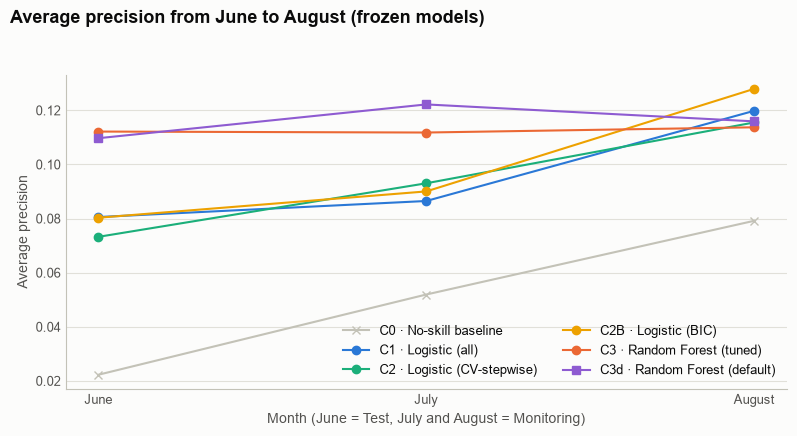

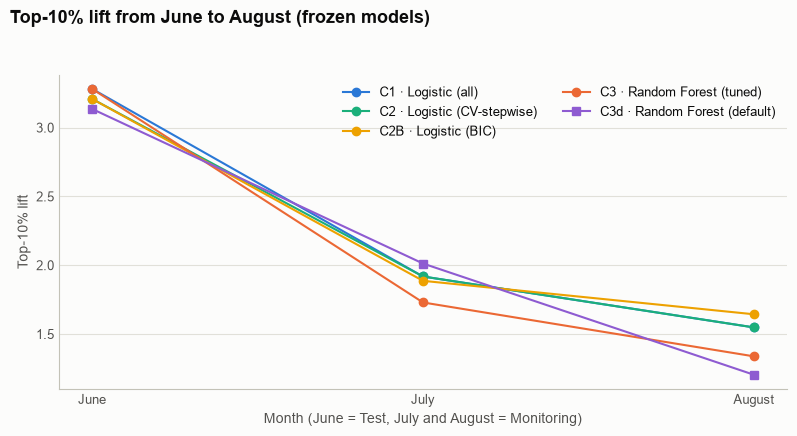

In [31]:
drift = ev.drift_table(results, ['avg_precision', 'roc_auc', 'brier', 'precision_top10', 'top10_lift', 'late_rate'])
drift.round(4).to_csv(OUT / 'drift_long.csv', index=False)
drift_view = ml.add_model_columns(drift.round(4))
display(drift_view)
for metric, ylabel, name in [('avg_precision', 'Average precision', 'ap'), ('top10_lift', 'Top-10% lift', 'lift')]:
    mf.plot_drift(drift[drift['model'] != 'C0'] if name == 'lift' else drift, metric, ylabel,
                  save_path=FIG / f'02_drift_{name}.png')
    plt.show()

**Reading the results (June is the headline).**
- **June.** AP: C3 0.112, C3d 0.110, C1 0.081, C2B 0.080, C2 0.073, against a no-skill 0.022. Top-10% lift is 3.1 to 3.3 for every model (all pass the lift >= 2 criterion), and the top-10% precision is 7.1% to 7.3% for C1, C2 and C3. The forest's June AP advantage therefore comes from a few very high-ranked orders (see the PR curve), not from better top-10% selection.
- **Does the Random Forest justify itself?** The second criterion (top-10% precision at least 1.10 times the best of C1 and C2) **fails for both forests on June** (0.073 versus a 0.080 threshold) **and on Validation** (0.246 versus 0.336). In CV the forest looks clearly better (AP 0.269 versus 0.138 to 0.150), but that advantage does not carry over to Validation (AP 0.219 versus 0.242 for C1), where the plain logistic models rank better, and it is small on June. The simpler model is therefore competitive out of time.
- **Selection.** The CV-stepwise subset C2 (3 of 24 features: customer_state, promised_lead_days, route_type) is close to C1 on Validation AP (0.236 versus 0.242) with an eighth of the features and a Train minus CV AP gap of 0.001 (C1: 0.073), but its June AP is lower (0.073 versus 0.081). The BIC subset C2B (12 features) behaves like C1. The overlap table shows 3 features chosen by all four methods (customer_state, promised_lead_days, route_type).
- **Overfitting.** Train minus CV AP gaps: C2 0.001, C1 0.073, C2B 0.067, C3 0.129, C3d 0.747.
- **Drift.** Every model's ROC-AUC falls from June (0.64 to 0.70) to July (0.54 to 0.59) and August (0.43 for C3 to 0.60). The tuned forest degrades most: its August ROC-AUC is 0.426, below chance, while the plain logistic models stay around 0.57 to 0.60. AP rises for the linear models only because the late rate rises (2.2% in June, 5.2% in July, 7.9% in August; no-skill AP follows it), and top-10% lift falls from about 3.2 to 1.9 in July and 1.5 to 1.6 in August for the linear models (C3: 3.3, 1.7 and 1.3). The labels for July and August are measured at the same approval-plus-45-day cut-off as June.
- **Calibration of the means.** Mean predicted probabilities (0.06 to 0.10) track the Train late rate (8.8%), not June's 2.2%, so all models over-predict in June, a base-rate shift rather than a ranking failure.

## 10. Interpretation

### 10.1 Odds ratios from statsmodels (C1 and C2)

Each linear model is refitted with statsmodels `Logit` on the identical Train design (unweighted, same transformations). The assertion below checks that its coefficients equal scikit-learn's. Terms whose standard error exceeds 5 are weakly identified (identified terms have SE below about 1.1) and are skipped in that comparison; when C1 contains such a term its intercept is partly tied to it and is skipped too and flagged in the tables as **not identified (quasi-separation: no late orders among multi-state-seller orders)**; their odds ratios should not be read. Numeric inputs are standardised for modelling; the tables give odds ratios **per unit** (original scale; for log inputs, **per doubling**) and **per 1 SD**. Categorical effects are relative to their reference (state SP, route `1. All interstate`, single-method `credit_card`). Sine/cosine terms have no per-unit reading.

In [32]:
MAX_SE = 5  # Identified terms here have SE below 1.1; the unidentified one is above 60
NOT_IDENTIFIED = 'not identified (quasi-separation: no late orders among multi-state-seller orders)'
sm_results, coef_tables, coefficient_checks = {}, {}, {}
for label in ['C1', 'C2']:
    fitted = train_fits[label]
    pre = fitted.named_steps['preprocessor']
    design = pd.DataFrame(pre.transform(data.X_train), columns=readable_names(pre), index=data.train_df.index)
    result = fit_statsmodels(TASK, design, data.y_train)
    report = convergence_report(result)
    gap = assert_coefficients_match(fitted, result, max_se=MAX_SE)
    coef = coefficient_table(result, TASK, pre, data.cat_cols)
    coef['identification'] = np.where(coef['se'] > MAX_SE, NOT_IDENTIFIED, 'identified')
    sm_results[label], coef_tables[label] = result, coef
    coefficient_checks[label] = {'max_abs_gap_identified_terms': gap, 'converged': report['converged'],
                                 'unstable_terms': report['unstable_terms']}
    coef.to_csv(OUT / f'{label}_coefficients.csv', index=False)
print(json.dumps(coefficient_checks, indent=1, default=str))

{
 "C1": {
  "max_abs_gap_identified_terms": 0.00026419767962648777,
  "converged": true,
  "unstable_terms": {
   "seller_state_count": 133.4
  }
 },
 "C2": {
  "max_abs_gap_identified_terms": 0.0002491986117676426,
  "converged": true,
  "unstable_terms": {}
 }
}


In [33]:
def odds_ratio_view(coef):
    """Readable odds-ratio table: per unit, per doubling for log inputs, and per 1 SD."""
    view = coef[coef['term'] != 'const'].copy()
    def ci(lo, hi):
        return [f'{a:.3f} to {b:.3f}' if pd.notna(a) else '' for a, b in zip(lo, hi)]

    table = pd.DataFrame({
        'Term': view['term'], 'Basis': view['per_unit_basis'],
        'OR per unit': view['effect_per_unit'].round(3), '95% CI per unit': ci(view['effect_per_unit_low'], view['effect_per_unit_high']),
        'OR per 1 SD': view['effect_per_sd'].round(3), '95% CI per 1 SD': ci(view['effect_per_sd_low'], view['effect_per_sd_high']),
        'p-value': view['p_value'].map(lambda p: '<0.001' if p < 0.001 else f'{p:.3f}'),
        'Identification': np.where(view['identification'] == 'identified', '', 'NOT IDENTIFIED (quasi-separation)')}).reset_index(drop=True)
    unidentified = table['Identification'] != ''
    table.loc[unidentified, ['OR per unit', 'OR per 1 SD']] = np.nan
    table.loc[unidentified, ['95% CI per unit', '95% CI per 1 SD', 'p-value']] = ''
    return table


odds_c2 = odds_ratio_view(coef_tables['C2'])
odds_c1 = odds_ratio_view(coef_tables['C1'])
print('C2 (CV-stepwise logistic): odds ratios'); display(odds_c2)
print('C1 (all 24 features): odds ratios'); display(odds_c1)

C2 (CV-stepwise logistic): odds ratios


,Term,Basis,OR per unit,95% CI per unit,OR per 1 SD,95% CI per 1 SD,p-value,Identification
0,promised_lead_days,per 1 unit,0.955,0.948 to 0.961,0.707,0.673 to 0.743,<0.001,
1,customer_state_AC,vs reference level,1.151,0.355 to 3.734,NaN,,0.815,
2,customer_state_AL,vs reference level,4.408,3.171 to 6.130,NaN,,<0.001,
3,customer_state_AM,vs reference level,0.964,0.299 to 3.106,NaN,,0.951,
4,customer_state_AP,vs reference level,0.671,0.091 to 4.954,NaN,,0.696,
5,customer_state_BA,vs reference level,1.790,1.507 to 2.125,NaN,,<0.001,
6,customer_state_CE,vs reference level,1.617,1.251 to 2.090,NaN,,<0.001,
7,customer_state_DF,vs reference level,0.817,0.636 to 1.049,NaN,,0.113,
8,customer_state_ES,vs reference level,1.017,0.808 to 1.279,NaN,,0.886,
9,customer_state_GO,vs reference level,0.926,0.725 to 1.183,NaN,,0.539,


C1 (all 24 features): odds ratios


,Term,Basis,OR per unit,95% CI per unit,OR per 1 SD,95% CI per 1 SD,p-value,Identification
0,order_approved_day_of_week_sin,n/a,NaN,,NaN,,<0.001,
1,order_approved_day_of_week_cos,n/a,NaN,,NaN,,0.025,
2,order_approved_day_of_month,per 1 unit,1.004,1.000 to 1.008,1.036,0.998 to 1.075,0.066,
3,order_approved_month_sin,n/a,NaN,,NaN,,<0.001,
4,order_approved_month_cos,n/a,NaN,,NaN,,<0.001,
5,order_item_count,per 1 unit,0.844,0.773 to 0.921,0.913,0.871 to 0.957,<0.001,
6,order_seller_count,per 1 unit,0.260,0.116 to 0.581,0.852,0.775 to 0.938,0.001,
7,log_order_frieght_value_sum,per doubling,0.951,0.851 to 1.062,0.964,0.889 to 1.045,0.371,
8,log_order_product_weight_g_sum,per doubling,0.995,0.964 to 1.027,0.990,0.931 to 1.053,0.744,
9,order_product_category_count,per 1 unit,0.913,0.467 to 1.784,0.992,0.935 to 1.053,0.790,


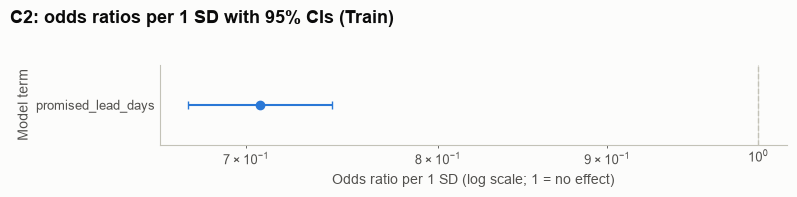

In [34]:
identified = coef_tables['C2'][coef_tables['C2']['identification'] == 'identified']
mf.plot_effects_forest(identified, 'Odds ratio per 1 SD (log scale; 1 = no effect)',
                       FIG / '02_c2_odds_ratios.png', title='C2: odds ratios per 1 SD with 95% CIs (Train)')
plt.show()

### 10.2 Hypothesis check

The six feature-engineering hypotheses (time, workload, order, distance, payment, promise) with the expected sign on late delivery. A verdict of agree or disagree needs a significant coefficient (p < 0.05); otherwise "not significant", or "not in model" when stepwise dropped the feature.

In [35]:
hypothesis = hypothesis_check_table({'C1': coef_tables['C1'], 'C2': coef_tables['C2']})
not_identified_terms = {t for tbl in coef_tables.values() for t in tbl.loc[tbl['identification'] != 'identified', 'term']}
hypothesis.loc[hypothesis['term'].isin(not_identified_terms), 'verdict'] = 'not identified'
hypothesis_view = ml.add_model_columns(hypothesis.assign(coef=hypothesis['coef'].round(3), p_value=hypothesis['p_value'].round(4)))
display(hypothesis_view)
display(hypothesis.groupby(['model', 'verdict']).size().unstack(fill_value=0))

,Code,Model,hypothesis,feature,expected_sign,term,coef,p_value,observed_sign,verdict
0,C1,Logistic (all),time,is_weekend_approval,+,is_weekend_approval,-0.071,0.0083,-,disagree
1,C1,Logistic (all),time,is_black_friday_period,+,is_black_friday_period,0.234,0.0000,+,agree
2,C1,Logistic (all),time,is_december_peak,+,is_december_peak,0.114,0.0000,+,agree
3,C1,Logistic (all),workload,orders_approved_prev_7d,+,log_orders_approved_prev_7d,0.090,0.0004,+,agree
4,C1,Logistic (all),workload,approval_lag_hours,+,log_approval_lag_hours,0.151,0.0000,+,agree
5,C1,Logistic (all),order,order_item_count,+,order_item_count,-0.091,0.0002,-,disagree
6,C1,Logistic (all),order,order_seller_count,+,order_seller_count,-0.160,0.0010,-,disagree
7,C1,Logistic (all),order,order_product_weight_g_sum,+,log_order_product_weight_g_sum,-0.010,0.7436,-,not significant
8,C1,Logistic (all),order,order_product_volume_cm3_sum,+,log_order_product_volume_cm3_sum,0.101,0.0002,+,agree
9,C1,Logistic (all),distance,seller_dist_km_mean,+,log_seller_dist_km_mean,0.080,0.0186,+,agree


verdict,agree,disagree,not identified,not in model,not significant
model,,,,,
C1,8,3,1,0,2
C2,1,0,0,13,0


### 10.3 Calibration

Reliability curves on Validation and on June (equal-count bins). A model whose points lie on the diagonal gives probabilities that can be read as risks. This matters because the final models are not rebalanced.

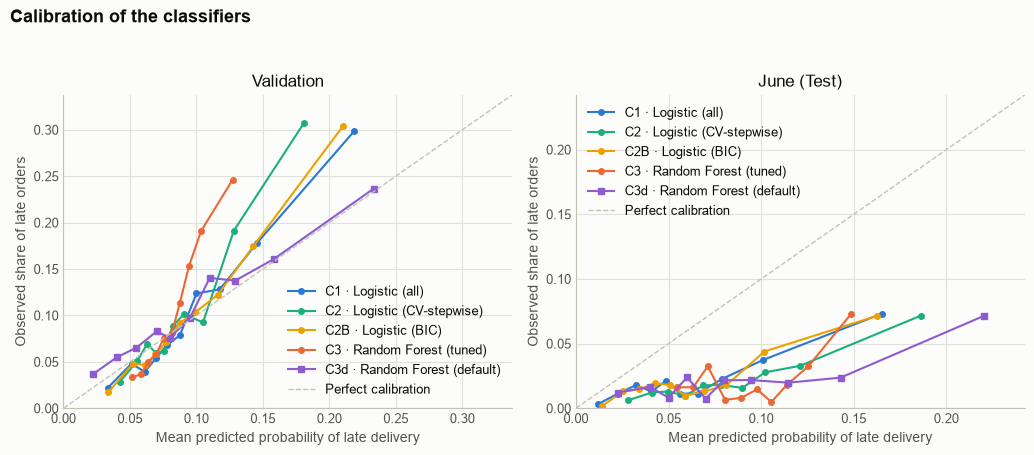

,Validation,June
C1,0.0962,0.0623
C2,0.0884,0.0820
C2B,0.0950,0.0640
C3,0.0813,0.0951
C3d,0.0949,0.0862
Observed late rate,0.1038,0.0223


In [36]:
known_june = june_scored['C0'].dropna(subset=['actual_label'])
curve_labels = ['C1', 'C2', 'C2B', 'C3', 'C3d']
panels = {'Validation': {l: (data.y_validation, validation_probs[l]) for l in curve_labels},
          'June (Test)': {l: (june_scored[l].dropna(subset=['actual_label'])['actual_label'].astype(int),
                              june_scored[l].dropna(subset=['actual_label'])['predicted_probability'])
                          for l in curve_labels}}
mf.plot_calibration(panels, FIG / '02_calibration.png', title='Calibration of the classifiers')
plt.show()
mean_prob = pd.DataFrame({'Validation': {l: validation_probs[l].mean() for l in curve_labels},
                          'June': {l: june_scored[l]['predicted_probability'].mean() for l in curve_labels}}).round(4)
mean_prob.loc['Observed late rate'] = [data.y_validation.mean(), known_june['actual_label'].astype(int).mean()]
display(mean_prob.round(4))

### Precision-recall curves

Precision against recall for the plain logistic models (C1, C2) and the tuned forest (C3), on Validation and June. The dashed line is the no-skill precision (the late rate of the cohort); the dark-edged marker on each curve is the top-10% capacity operating point.

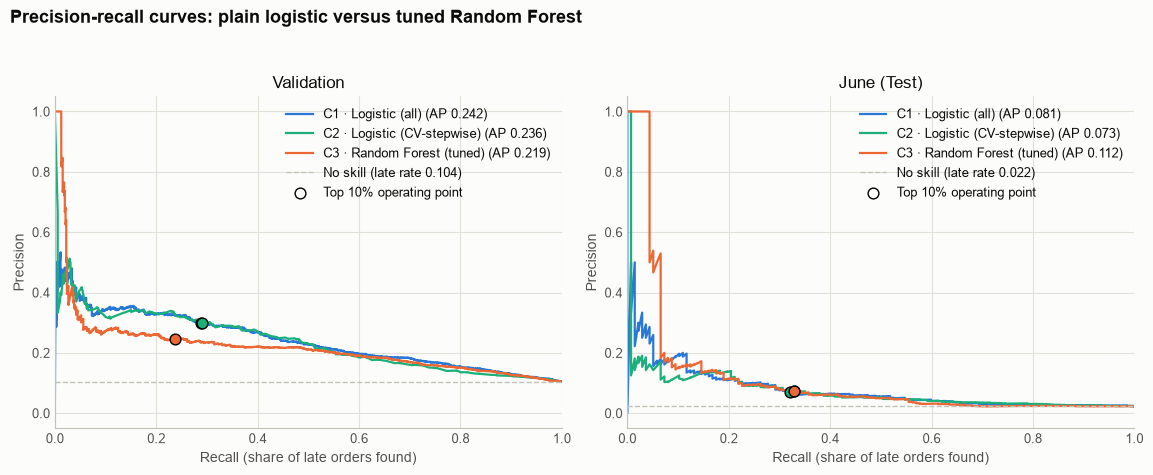

In [37]:
pr_panels = {name: {l: pair[l] for l in ['C1', 'C2', 'C3']} for name, pair in
             {'Validation': {l: (data.y_validation, validation_probs[l]) for l in curve_labels},
              'June (Test)': panels['June (Test)']}.items()}
mf.plot_pr_curves(pr_panels, FIG / '02_pr_curves.png', title='Precision-recall curves: plain logistic versus tuned Random Forest')
plt.show()

### ROC curves

True positive rate against false positive rate for C1, C2 and C3 on Validation and June. The top-left corner is best, the dashed diagonal is a model with no ranking skill (ROC-AUC 0.5), and the dark-edged marker on each curve is the top-10% capacity operating point. ROC-AUC measures ranking over all thresholds and is insensitive to how rare late orders are, so it can look flattering for an imbalanced target; average precision therefore stays the primary metric and these curves are a complement.

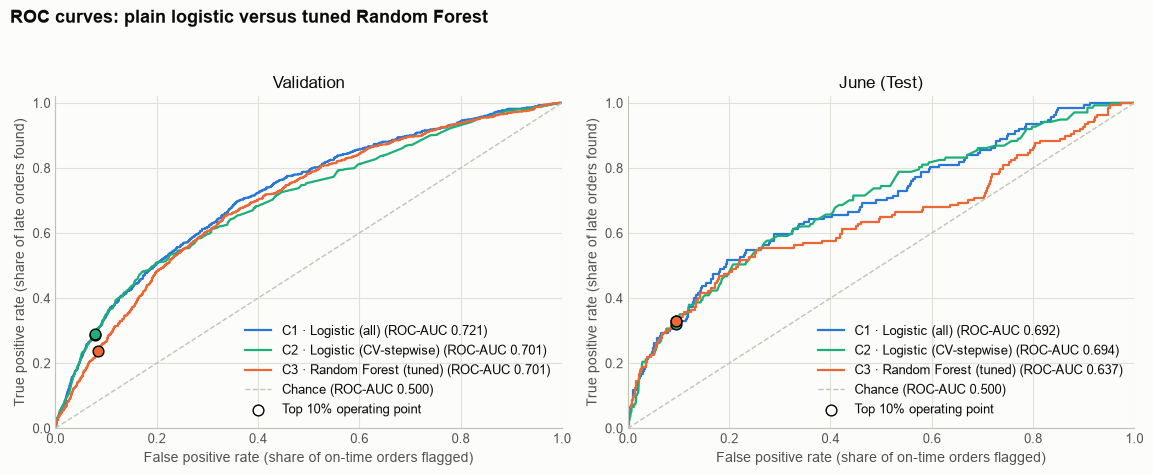

In [38]:
roc_panels = {name: {l: pair[l] for l in ['C1', 'C2', 'C3']} for name, pair in panels.items()}
mf.plot_roc_curves(roc_panels, FIG / '02_roc_curves.png', title='ROC curves: plain logistic versus tuned Random Forest')
plt.show()

### 10.4 Random Forest: permutation importance, partial dependence and agreement with the linear model

Permutation importance shuffles one raw feature at a time and measures the drop in AP (5 repeats): the Train-fitted C3 on Validation, and the June-fitted C3 on June. Partial-dependence plots show the average predicted late probability across the range of the top three features. The agreement table sets the forest's ten most important features beside the C1 odds-ratio significance. Permutation importance can understate correlated features and overstate those with many split points (Strobl et al., 2007, BMC Bioinformatics 8:25).

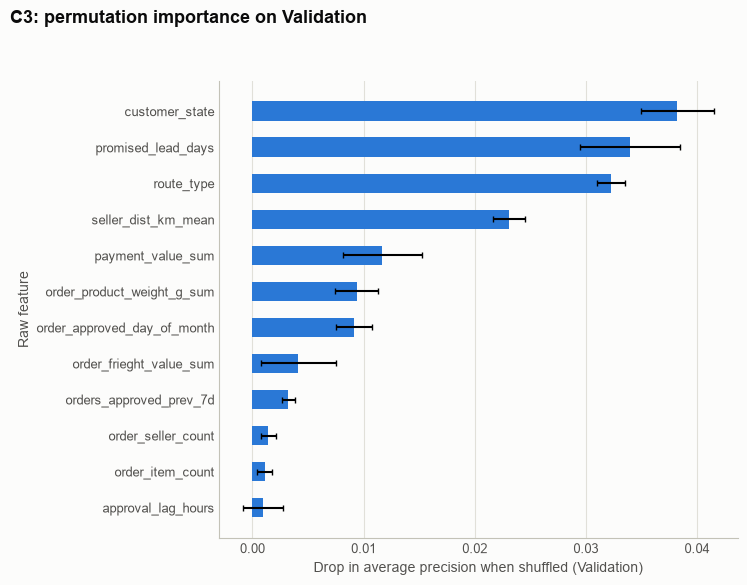

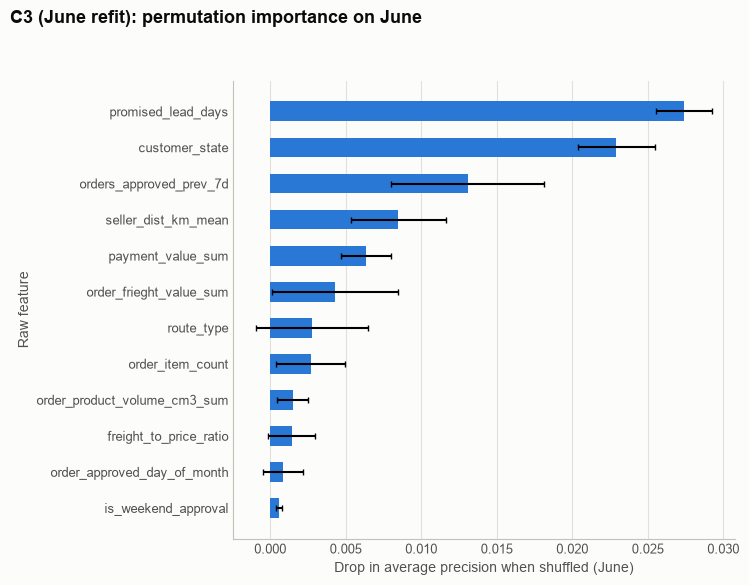

In [39]:
importance_validation = rf_permutation_importance(train_fits['C3'], data.X_validation, data.y_validation, 'average_precision')
june_X = final_df.set_index('order_id').loc[known_june['order_id'], FEATURES]
importance_june = rf_permutation_importance(june_fits['C3'], june_X, known_june['actual_label'].astype(int).to_numpy(), 'average_precision')
importance_validation.to_csv(OUT / 'rf_permutation_importance_validation.csv', index=False)
importance_june.to_csv(OUT / 'rf_permutation_importance_june.csv', index=False)
mf.plot_importance(importance_validation, 'Drop in average precision when shuffled (Validation)',
                   FIG / '02_rf_importance_validation.png', title='C3: permutation importance on Validation')
plt.show()
mf.plot_importance(importance_june, 'Drop in average precision when shuffled (June)',
                   FIG / '02_rf_importance_june.png', title='C3 (June refit): permutation importance on June')
plt.show()

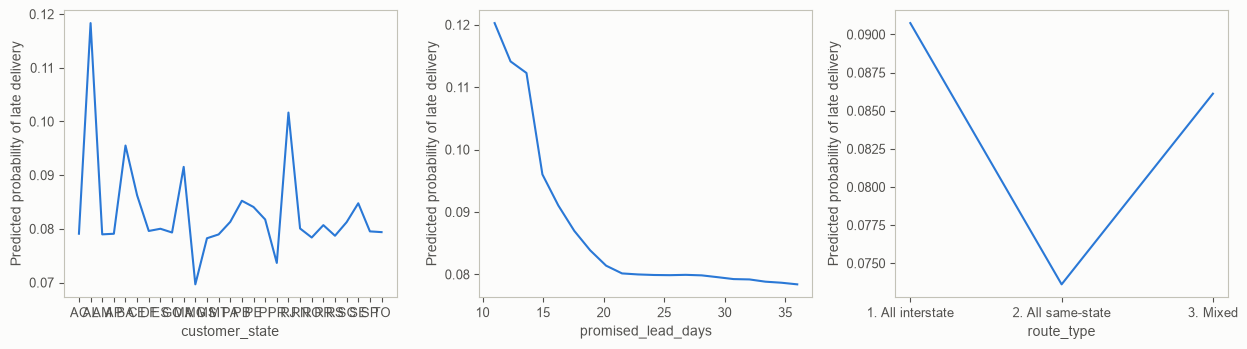

,rank,feature,importance_mean,linear_min_p,linear_significant
0,1,customer_state,0.0382,0.0000,True
1,2,promised_lead_days,0.0339,0.0000,True
2,3,route_type,0.0323,0.0000,True
3,4,seller_dist_km_mean,0.0231,0.0186,True
4,5,payment_value_sum,0.0117,0.0001,True
5,6,order_product_weight_g_sum,0.0094,0.7436,False
6,7,order_approved_day_of_month,0.0091,0.0664,False
7,8,order_frieght_value_sum,0.0041,0.3715,False
8,9,orders_approved_prev_7d,0.0032,0.0004,True
9,10,order_seller_count,0.0014,0.0010,True


In [40]:
top_features = importance_validation['feature'].head(3).tolist()
pdp = rf_partial_dependence(train_fits['C3'], data.X_validation.astype({c: float for c in data.num_cols}), top_features, categorical=data.cat_cols)
plot_partial_dependence(pdp, 'Predicted probability of late delivery', FIG / '02_rf_partial_dependence.png')
plt.show()
agreement = agreement_table(importance_validation, coef_tables['C1'])
agreement['importance_mean'] = agreement['importance_mean'].round(4)
agreement['linear_min_p'] = agreement['linear_min_p'].round(4)
display(agreement)

**Reading the interpretation.**
- **Odds ratios.** In C2, `promised_lead_days` has an odds ratio of 0.955 per day (0.71 per 1 SD): a longer promise makes lateness less likely, the strongest and most stable effect. State effects (for example AL 4.4, MA 2.6, BA 1.8 versus SP; MG 0.59) and the same-state route (OR 0.42) matter, and the all-features model C1 adds the Black Friday (OR 2.24) and December peak (OR 1.41) flags. `seller_state_count` is **not identified** in C1 (no late orders among multi-state-seller orders), so its odds ratio and p-value are suppressed and its hypothesis verdict is "not identified".
- **Hypotheses (C1).** 8 of 14 expectations agree in sign and significance (Black Friday, December, workload, volume, distance, payment value, promise); 3 disagree (weekend approval, item count and seller count are negatively associated with lateness, opposite to the expected sign, possibly because they proxy for simple, same-region orders); 2 are not significant; 1 is not identified. C2 retains only 1 of the hypothesised features, so most of its rows read "not in model".
- **Calibration.** Without rebalancing, the models' probabilities are on the right scale on Validation (mean predicted 0.08 to 0.10 versus observed 0.104) but over-predict in June (about 0.06 to 0.10 versus an observed 0.022), because they were fitted on history with a higher late rate.
- **Random Forest.** Permutation importance (Validation) is led by customer_state, promised_lead_days and route_type, then seller_dist_km_mean and payment_value_sum. Seven of its top ten features are also significant in C1; the exceptions (product weight, day of month, freight value) matter to the forest but not to the logistic model, which suggests non-linear or interaction effects there. The partial-dependence plots show the shapes behind these rankings. Permutation importance is computed on a model whose out-of-time AP is modest, so treat the ranking as indicative.

## 11. Exports and run metadata

Report tables are exported as HTML, LaTeX and CSV with `export_report_tables`; `run_metadata.json` records dates, row counts, features, transformations, selections, forest parameters, package versions and model fingerprints for the summary notebook.

In [41]:
def table_item(title, frame, note='', prose=''):
    return {'title': title, 'frame': frame, 'note': note, 'prose': prose}


exports = {
    'classification_model_comparison': [table_item(f'Classification: {t}', tbl, 'Train is in-sample; CV is mean +/- SD over 5 chronological folds; June is Test; July and August are Monitoring.')
                                        for t, tbl in comparison_tables.items()],
    'classification_success_criteria': [table_item('Classification: success criteria', criteria_display)],
    'classification_overfitting_gaps': [table_item('Classification: overfitting gap (Train minus CV mean)', gaps)],
    'classification_june_deciles': [table_item('June: cumulative capture of late orders by risk decile (%)', ml.label_model_columns(capture.reset_index())),
                                    table_item('June: lift by risk decile', ml.label_model_columns(lift_by_decile.reset_index()))],
    'classification_drift': [table_item('Classification: drift from June to August', drift_view)],
    'classification_rf_tuning_gain': [table_item(f"Random Forest: tuned minus default ({ml.display_name('C3')} minus {ml.display_name('C3d')})", tuning_gain.round(4),
                                                 'Positive gain is better except for Brier. Gaps are Train minus CV mean.')],
    'classification_stepwise_path': [table_item('CV-stepwise path', cv_path.round(4))],
    'classification_selection_overlap': [table_item('Variable selection overlap', overlap)],
    'classification_class_weight_sensitivity': [table_item('C1 class-weight sensitivity (CV)', class_weight_sensitivity.reset_index().rename(columns={'index': 'Model'}))],
    'classification_resampling': [table_item('Class-imbalance options (CV and Validation)', resampling_table)],
    'classification_odds_ratios': [table_item('C2 odds ratios', odds_c2), table_item('C1 odds ratios', odds_c1)],
    'classification_hypothesis_check': [table_item('Hypothesis check', hypothesis_view)],
    'classification_rf_search_summary': [table_item('Random Forest search space', space), table_item('Random Forest search summary', summary),
                                         table_item('Stage B top candidates', top_candidates)],
    'classification_rf_agreement': [table_item('Random Forest top features versus C1 significance', agreement)],
}
for stem, items in exports.items():
    export_report_tables(items, OUT, stem)
print(f'{len(exports)} table groups exported to {OUT}')

14 table groups exported to results/simple_to_complex/classification


In [42]:
def headline(label, split):
    row = results[(results['model'] == label) & (results['split'] == split)].iloc[0]
    return {k: float(row[k]) for k in ['avg_precision', 'roc_auc', 'brier', 'precision_top10', 'top10_lift', 'late_rate']}


metadata = {
    'task': TASK, 'run_date': RUN_DATE, 'lookback_days': LOOKBACK, 'random_state': RANDOM_STATE,
    'dates': {'train': [str(data.train_df['order_approved_dt'].min()), str(data.train_df['order_approved_dt'].max())],
              'validation': [str(data.validation_df['order_approved_dt'].min()), str(data.validation_df['order_approved_dt'].max())],
              'test_june': ['2018-06-01', '2018-06-30'], 'monitoring': ['2018-07-01', '2018-08-31']},
    'row_counts': {**data.counts(), 'train_late': int(data.y_train.sum()), 'validation_late': int(data.y_validation.sum()),
                   'june_scored': len(june_ids), 'june_known': int(june_labels.notna().sum()),
                   'july_scored': len(monitoring['C0']['2018-07']), 'august_scored': len(monitoring['C0']['2018-08'])},
    'features': {'numeric': data.num_cols, 'categorical': data.cat_cols},
    'linear_transforms': {'log_cols': LOG_COLS, 'cyclic': True, 'merge_mixed_route': True, 'squared_cols': [],
                          'rule': 'pre-specified'},
    'selected_variables': {'C1': FEATURES, 'C2': C2_UNITS, 'C2B': BIC_UNITS, 'AIC': AIC_UNITS, 'Lasso': lasso['selected_units']},
    'stepwise': {'best_step': best_step, 'one_se_step': chosen_step, 'lasso_C': lasso['penalty']},
    'rf_best_params': RF_PARAMS, 'rf_search': {k: meta[k] for k in ['n_iter_stage_a', 'best_cv_mean', 'best_cv_sd', 'stage_a_seconds', 'stage_b_seconds']},
    'rf_default_params': {'n_estimators': 100, 'random_state': RANDOM_STATE, 'other': 'scikit-learn defaults'},
    'resampling': {'adopted': False, 'clear_ap_gain_any': bool(resampling_summary['clear_ap_gain'].any()),
                   'ap_gain_vs_none': {f'{r.model}/{r.strategy}': round(r.ap_gain_vs_none, 5) for r in resampling_summary.itertuples()}},
    'fingerprints': {label: f['before_june'] for label, f in fingerprints.items()},
    'logistic_convergence': {label: convergence[label] for label in LINEAR},
    'coefficient_checks': coefficient_checks,
    'headline_june': {label: headline(label, 'June') for label in SPECS},
    'headline_validation': {label: headline(label, 'Validation') for label in SPECS},
    'versions': {'python': platform.python_version(), 'scikit-learn': sklearn.__version__, 'numpy': np.__version__,
                 'pandas': pd.__version__, 'statsmodels': statsmodels.__version__, 'imbalanced-learn': imblearn.__version__},
}
(OUT / 'run_metadata.json').write_text(json.dumps(metadata, indent=2, default=str))

9848